# 2장 — 연산 단위 분해와 Attention

1장은 추론 한 스텝을 **하나의 숫자**로 다뤘습니다. FLOPs와 bytes를 세어 roofline에 얹고,
prefill은 compute-bound, decode는 memory-bound라고 분류했죠.

그런데 그 분류만으로는 아직 손을 댈 수 없습니다. "decode가 memory-bound"라는 말은
*무엇을* 고쳐야 하는지 알려주지 않습니다. 스텝 안에는 열 개가 넘는 연산이 들어 있고,
그중 시간을 먹는 것은 몇 개뿐입니다.

2장은 그 덩어리를 **연산 단위로 쪼개고, 각 단위가 실제로 쓴 시간을 잽니다.**
그리고 그 비율이 가리키는 곳 — attention과 KV 캐시 — 을 끝까지 파고듭니다.

### 이 장에서 다루는 것

| 절 | 주제 |
|---|---|
| §1 | 한 layer의 해부 — $X \rightarrow Q,K,V \rightarrow \text{Attention} \rightarrow O \rightarrow \text{MLP}$ |
| §2 | 연산 단위 분해 계측 — 어디에서 시간이 사라지는가 |
| §3 | 시간 비중 vs FLOPs 비중 — 두 표를 겹쳐 읽기 |
| §4 | RoPE 사례 연구 — 계측이 찾아낸 두 개의 결함 |
| §5 | causal mask와 decode attention |
| §6 | MHA / MQA / GQA |
| §7 | FlashAttention |
| §8 | KV cache layout |
| §9 | PagedAttention |
| §10 | Sampling |
| §11 | 정리와 연습문제 |

### 2장에서 가져가야 할 단 하나의 직관

**시간 비중과 연산량 비중은 일치하지 않습니다. 그 불일치가 최적화 대상입니다.**

RMSNorm은 이 모델 전체 FLOPs의 0%를 차지하는데 prefill 시간의 14%를 씁니다.
RoPE도 FLOPs로는 0%인데 decode 시간의 12%를 먹습니다.
반대로 MLP는 FLOPs의 60%를 쓰면서 시간은 39%만 씁니다.

FLOPs가 0인데 시간을 쓰는 연산은 **연산이 아니라 메모리와 커널 실행**에 돈을 쓰고 있습니다.
1장의 roofline이 모델 전체에 대해 한 이야기를, 이 장은 연산 하나하나에 대해 다시 합니다.

## §0. 준비 — 이 숫자들이 어느 기계에서 나왔는지

1장과 같은 모델(246M, GQA 16:4)을 씁니다. 다만 **batch를 8로 올립니다.**

1장에서 봤듯 이 호스트에서 batch 1 decode는 launch-bound입니다 — GPU가 일하는 시간보다
파이썬이 커널을 밀어넣는 시간이 깁니다. 그 상태로 연산별 비율을 재면
"전부 launch overhead"라는 답만 나오고, 정작 알고 싶은 연산 간 비율은 묻히죠.
batch 8은 GPU에 실제 일을 주면서도 8 GB 안에 들어오는 타협점입니다.
(그렇다고 gap이 사라지지는 않습니다. §2에서 그 크기를 직접 확인합니다.)

**그리고 측정 전에 GPU를 깨웁니다.** 유휴 상태의 카드는 SM 클럭을 부스트의 1/6 수준까지 낮춰 두고, 부하가 걸려도 즉시 올라오지 않습니다. 세션의 첫 측정이 그 구간에 걸리면 결과가 몇 배 느리게 나오죠 — 코드가 느린 게 아니라 하드웨어가 자고 있던 겁니다. 이 노트북의 초안이 정확히 그 함정에 빠졌고, 그래서 `warmup_device`가 생겼습니다. 1장 §1의 '측정의 규율'에 한 줄 더 붙는 셈입니다.

In [1]:
import time

import matplotlib.pyplot as plt
import torch

from infer_opt import opprofile as opp
from infer_opt import profiling as prof
from infer_opt.config import ModelConfig, RunConfig
from infer_opt.runner import prepare, synchronize

torch.manual_seed(0)

# 1장과 같은 실험 대상 모델 (GQA 16:4, SwiGLU, RoPE, 246M params)
CFG = ModelConfig(
    vocab_size=32000,
    hidden_size=1024,
    n_layers=16,
    n_heads=16,
    n_kv_heads=4,
    intermediate_size=2816,
    max_seq_len=2048,
)
BATCH, PROMPT_LEN = 8, 1024
RUN = RunConfig(batch_size=BATCH, prompt_len=PROMPT_LEN, decode_len=64, device="auto", dtype="float16")

model, DEVICE, DTYPE, PROMPT, CONTINUATION = prepare(CFG, RUN)
INFO = prof.device_summary(DEVICE)

# 첫 측정 전에 GPU 클럭을 깨운다. 유휴 상태의 카드는 SM 클럭을 부스트의 1/6까지
# 떨어뜨려 두고, 올라오는 데 시간이 걸린다. 그 구간에서 재면 코드가 아니라
# 잠든 하드웨어를 재게 된다 (이 노트북 초안이 실제로 그랬다).
opp.warmup_device(DEVICE, seconds=3.0)

for key, value in INFO.items():
    print(f"{key:>20} : {value}")
print(f"{'params':>20} : {prof.parameter_count(CFG) / 1e6:.0f}M")
print(f"{'batch':>20} : {BATCH}")
print(f"{'prompt tokens':>20} : {PROMPT_LEN}")

              device : cuda
               torch : 2.14.0+cu130
          cuda_build : 13.0
                name : NVIDIA GeForce RTX 2080 SUPER
  compute_capability : 7.5
            sm_count : 48
     total_memory_gb : 8.589606912
      bf16_supported : True
              params : 246M
               batch : 8
       prompt tokens : 1024


### 그래프 테마

1장과 같은 색을 씁니다. 파랑은 prefill, 주황은 decode, 초록은 강조입니다.

In [2]:
PREFILL_COLOR, DECODE_COLOR, ACCENT_COLOR = "#2a78d6", "#eb6834", "#1baf7a"
SURFACE, INK, INK_SOFT, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3de"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#d8d7d2", "axes.labelcolor": INK_SOFT, "text.color": INK,
        "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "grid.color": GRID,
        "axes.grid": True, "grid.linewidth": 0.8, "axes.axisbelow": True,
        "axes.spines.top": False, "axes.spines.right": False,
        "font.size": 11, "figure.dpi": 110, "lines.linewidth": 2, "lines.markersize": 7,
        "axes.titlesize": 12, "axes.titlelocation": "left", "axes.titlepad": 12,
    }
)
print("theme ready")

theme ready


## §1. 한 layer의 해부

decoder layer 하나가 하는 일은 이게 전부입니다.

$$X \;\rightarrow\; \text{RMSNorm} \;\rightarrow\; Q,K,V \;\rightarrow\; \text{RoPE} \;\rightarrow\; \text{Attention} \;\rightarrow\; O \;\rightarrow\; \text{RMSNorm} \;\rightarrow\; \text{MLP}$$

잔차 연결까지 쓰면:

$$X' = X + O(\text{Attn}(\text{RoPE}(QKV(\text{Norm}(X))))) \qquad X'' = X' + \text{MLP}(\text{Norm}(X'))$$

중요한 건 **텐서의 모양이 어디서 바뀌는가**입니다. 특히 GQA에서는 $K,V$가 $Q$보다 좁습니다.
`n_heads=16`, `n_kv_heads=4`이므로 K와 V는 Q의 1/4 크기죠. 이 비대칭이 §6의 주제이고,
KV 캐시 용량을 결정합니다.

아래는 실제 텐서를 흘려보내며 각 단계의 모양을 찍은 것입니다. 숫자를 외울 필요는 없고,
**어디서 `hidden_size`가 head로 쪼개지고 어디서 다시 합쳐지는지**만 보세요.

In [3]:
def trace_shapes(tokens: int, context: int) -> list[tuple[str, tuple[int, ...], str]]:
    """한 layer를 통과하는 텐서의 모양을 단계별로 기록한다 (계산은 하지 않는다)."""
    h, heads, kv_heads, d = CFG.hidden_size, CFG.n_heads, CFG.n_kv_heads, CFG.head_dim
    inter = CFG.intermediate_size
    return [
        ("X                 입력", (BATCH, tokens, h), "hidden_size"),
        ("Norm(X)            RMSNorm", (BATCH, tokens, h), "모양 불변, 값만 정규화"),
        ("Q                  q_proj", (BATCH, heads, tokens, d), f"{heads} heads x {d}"),
        ("K, V               k/v_proj", (BATCH, kv_heads, tokens, d), f"{kv_heads} heads x {d}  <- GQA: 1/{heads // kv_heads} 폭"),
        ("RoPE(Q), RoPE(K)   회전", (BATCH, heads, tokens, d), "모양 불변, 위치 정보 주입"),
        ("KV cache           누적", (BATCH, kv_heads, context, d), f"context={context}로 자란다"),
        ("Attn(Q, K, V)      attention", (BATCH, heads, tokens, d), "K,V는 캐시 전체를 본다"),
        ("O                  o_proj", (BATCH, tokens, h), "head를 다시 합친다"),
        ("gate, up           MLP 상행", (BATCH, tokens, inter), f"{inter / h:.2f}x 확장"),
        ("down               MLP 하행", (BATCH, tokens, h), "다시 hidden_size"),
    ]


for phase, tokens, context in [("PREFILL", PROMPT_LEN, PROMPT_LEN), ("DECODE", 1, PROMPT_LEN + 1)]:
    print(f"\n{phase}  (tokens={tokens}, context={context})")
    print(f"  {'stage':<34} {'shape':<26} note")
    for name, shape, note in trace_shapes(tokens, context):
        print(f"  {name:<34} {str(tuple(shape)):<26} {note}")


PREFILL  (tokens=1024, context=1024)
  stage                              shape                      note
  X                 입력               (8, 1024, 1024)            hidden_size
  Norm(X)            RMSNorm         (8, 1024, 1024)            모양 불변, 값만 정규화
  Q                  q_proj          (8, 16, 1024, 64)          16 heads x 64
  K, V               k/v_proj        (8, 4, 1024, 64)           4 heads x 64  <- GQA: 1/4 폭
  RoPE(Q), RoPE(K)   회전              (8, 16, 1024, 64)          모양 불변, 위치 정보 주입
  KV cache           누적              (8, 4, 1024, 64)           context=1024로 자란다
  Attn(Q, K, V)      attention       (8, 16, 1024, 64)          K,V는 캐시 전체를 본다
  O                  o_proj          (8, 1024, 1024)            head를 다시 합친다
  gate, up           MLP 상행          (8, 1024, 2816)            2.75x 확장
  down               MLP 하행          (8, 1024, 1024)            다시 hidden_size

DECODE  (tokens=1, context=1025)
  stage                              shape                      n

두 표의 차이가 이 장 전체를 요약합니다.

**prefill과 decode는 같은 코드를 지나지만 모양이 다릅니다.** prefill에서 $Q$는
`[8, 16, 1024, 64]`인 행렬이고, decode에서는 `[8, 16, 1, 64]`인 **벡터**입니다.
가중치는 그대로인데 곱해지는 쪽이 1024개에서 1개로 줄었죠 — 1장에서 본 GEMM → GEMV 전환입니다.

반면 **KV 캐시만은 decode에서도 크기가 유지되고 오히려 자랍니다.**
`[8, 4, 1025, 64]`를 읽어서 `[8, 16, 1, 64]` 하나를 만듭니다.
읽는 양과 만드는 양의 이 격차가 decode attention이 memory-bound인 이유입니다.

## §2. 연산 단위 분해 계측

이제 직접 잽니다.

프로파일러는 커널을 봅니다 — `aten::mm` 같은 이름으로요. 문제는 `q_proj`도 `o_proj`도
MLP의 세 projection도 전부 `aten::mm`이라, 끝난 뒤에는 구분할 방법이 없다는 겁니다.
그래서 `infer_opt.model`은 forward 경로의 각 구간에 이름을 붙여 뒀습니다
(`infer_opt.regions.region`). 평소에는 꺼져 있어 비용이 0이고,
`opprofile.profile_stages`가 도는 동안만 켜집니다.

**한 가지 규율을 먼저.** 아래에서 나오는 `device` 합계는 GPU가 실제로 일한 시간이고,
`wall`은 벽시계 시간입니다. 둘의 차이(`gap`)는 GPU가 놀면서 다음 커널을 기다린 시간입니다.
연산 간 *비율*은 device 시간으로 읽어야 하고, **그 gap의 크기 자체가 또 하나의 측정 결과**입니다.

In [4]:
# 측정 전 클럭을 다시 올린다. 셀 사이의 파이썬 구간 동안 카드는 유휴 클럭으로
# 떨어지고, 그대로 재면 이 셀에서 '첫 번째로 측정한 것'만 몇 배 느리게 나온다.
opp.warmup_device(DEVICE)

@torch.inference_mode()
def measure_breakdown() -> tuple[opp.StageBreakdown, opp.StageBreakdown]:
    cache = model.new_cache(BATCH, DEVICE, DTYPE)

    def prefill_step() -> None:
        cache.reset()
        model.forward_prefill(PROMPT, cache)

    prefill = opp.profile_stages(prefill_step, device=DEVICE, warmup=2, iters=5)

    # decode는 캐시가 채워진 상태에서 재야 의미가 있다. 매 반복 같은 위치로 되돌려
    # 문맥 길이를 고정한다 (그러지 않으면 캐시가 자라며 조건이 달라진다).
    cache.reset()
    model.forward_prefill(PROMPT, cache)
    next_token = CONTINUATION[:, :1]

    def decode_step() -> None:
        cache.position = PROMPT_LEN
        model.forward_decode(next_token, cache)

    decode = opp.profile_stages(decode_step, device=DEVICE, warmup=5, iters=20)
    return prefill, decode


PREFILL_BD, DECODE_BD = measure_breakdown()

print(f"{'stage':>11} {'prefill ms':>11} {'share':>7}   {'decode ms':>10} {'share':>7}")
for stage in PREFILL_BD.stages:
    print(f"{stage:>11} {PREFILL_BD.stages[stage]:>11.3f} {PREFILL_BD.shares[stage]:>7.1%}   "
          f"{DECODE_BD.stages[stage]:>10.3f} {DECODE_BD.shares[stage]:>7.1%}")
print(f"{'-' * 52}")
print(f"{'device':>11} {PREFILL_BD.device_ms:>11.3f}           {DECODE_BD.device_ms:>10.3f}")
print(f"{'wall':>11} {PREFILL_BD.wall_ms:>11.3f}           {DECODE_BD.wall_ms:>10.3f}")
print(f"{'gap':>11} {PREFILL_BD.unattributed_ms:>11.3f}           {DECODE_BD.unattributed_ms:>10.3f}")
print(f"\nbusiest — prefill: {PREFILL_BD.busiest} / decode: {DECODE_BD.busiest}")

      stage  prefill ms   share    decode ms   share
  embedding       0.077    0.0%        0.008    0.1%
       norm      24.059   14.5%        0.639    9.0%
   qkv_proj      10.058    6.1%        0.287    4.1%
       rope      11.573    7.0%        0.493    7.0%
   kv_write       0.870    0.5%        0.057    0.8%
    kv_read       0.000    0.0%        0.000    0.0%
  attention      35.924   21.7%        4.440   62.7%
     o_proj       6.360    3.8%        0.118    1.7%
        mlp      63.852   38.6%        0.895   12.6%
    lm_head      12.608    7.6%        0.144    2.0%
----------------------------------------------------
     device     165.381                7.082
       wall     173.108               29.290
        gap       7.727               22.208

busiest — prefill: mlp / decode: attention


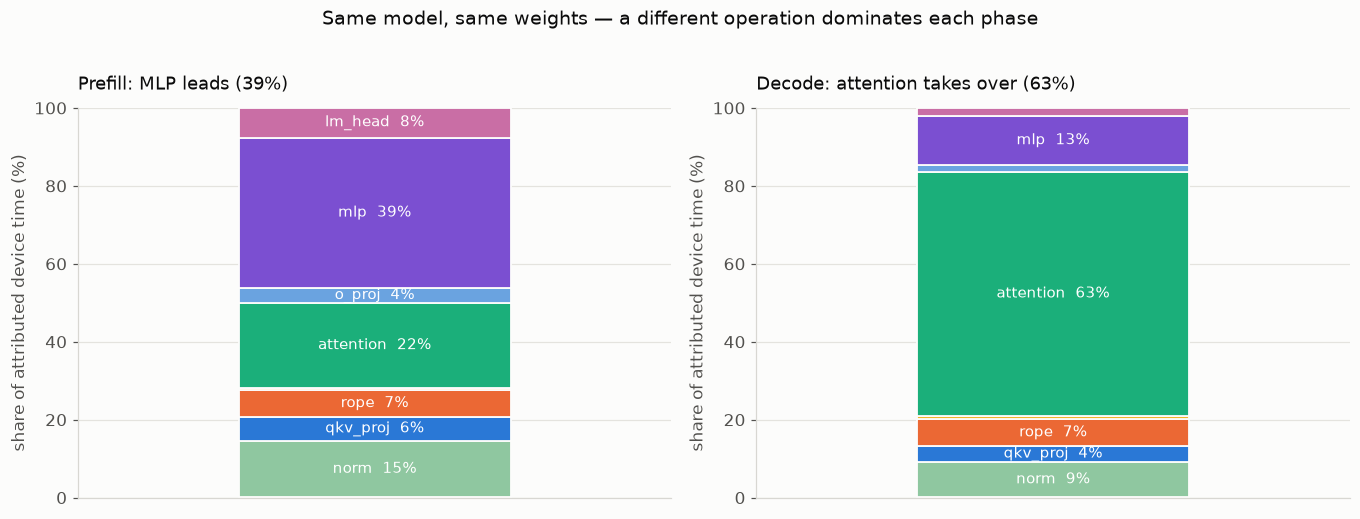

In [5]:
ORDER = ["embedding", "norm", "qkv_proj", "rope", "kv_write", "kv_read", "attention", "o_proj", "mlp", "lm_head"]
PALETTE = {
    "embedding": "#b9b8b2", "norm": "#8fc7a0", "qkv_proj": "#2a78d6", "rope": "#eb6834",
    "kv_write": "#f0b429", "kv_read": "#f7d774", "attention": "#1baf7a",
    "o_proj": "#6aa3e0", "mlp": "#7b4fd1", "lm_head": "#c96ea5",
}

figure, (left, right) = plt.subplots(1, 2, figsize=(12.5, 4.6))

for axis, breakdown, title in (
    (left, PREFILL_BD, f"Prefill: MLP leads ({PREFILL_BD.shares['mlp']:.0%})"),
    (right, DECODE_BD, f"Decode: attention takes over ({DECODE_BD.shares['attention']:.0%})"),
):
    bottom = 0.0
    for stage in ORDER:
        share = breakdown.shares[stage] * 100
        if share <= 0:
            continue
        axis.bar(0, share, bottom=bottom, width=0.55, color=PALETTE[stage], edgecolor=SURFACE, linewidth=1.2)
        if share > 3.5:
            axis.text(0, bottom + share / 2, f"{stage}  {share:.0f}%", ha="center", va="center",
                      color="white", fontsize=9.5,)
        bottom += share
    axis.set_title(title)
    axis.set_ylabel("share of attributed device time (%)")
    axis.set_xlim(-0.6, 0.6); axis.set_ylim(0, 100)
    axis.set_xticks([]); axis.grid(axis="x", visible=False)

figure.suptitle("Same model, same weights — a different operation dominates each phase",
                x=0.5, y=1.02, fontsize=12.5, color=INK)
figure.tight_layout()
plt.show()

### 여기서 읽어야 할 것

**1. prefill과 decode의 1위가 다릅니다.** prefill은 MLP가, decode는 attention이 가져갑니다.
같은 가중치, 같은 코드인데 최적화 대상이 뒤바뀝니다. prefill을 보고 세운 계획을
decode에 적용하면 엉뚱한 곳을 깎게 됩니다.

**2. `kv_read`가 0에 가깝습니다.** 놀랍지만 당연합니다 — `KVCache.read()`는 복사가 아니라
**슬라이스(view)** 입니다. 바이트는 하나도 움직이지 않죠. 그럼 KV를 읽는 비용은 어디 있을까요?
**attention 커널 안에 있습니다.** 캐시에서 데이터를 끌어오는 일은 attention이 하고,
그래서 decode attention이 저렇게 큽니다. §8에서 이 읽기를 직접 잽니다.

**3. `gap`이 작지 않습니다.** batch를 8로 올렸는데도 벽시계 시간의 상당 부분은 GPU가 논 시간입니다.
1장에서 본 launch-bound가 batch 8에서도 완전히 사라지지 않았다는 뜻입니다.
이 구간에서 커널 하나를 반으로 줄여도 벽시계는 그만큼 줄지 않습니다 —
줄일 수 있는 건 device 시간뿐이고, 나머지는 CUDA graph 같은 다른 처방이 필요합니다.

## §3. 시간 비중 vs FLOPs 비중

앞의 표는 "어디에 시간이 갔나"를 말해 줍니다. 그런데 **그게 정당한 시간인지**는 아직 모릅니다.
MLP가 시간을 많이 쓰는 건 일을 많이 해서일 수도 있고, 비효율적이어서일 수도 있죠.

판별법은 1장과 같습니다. **해야 할 일의 양과 쓴 시간을 나란히 놓는 것.**
`opprofile.stage_flops`는 각 구간이 수행해야 할 FLOPs를 셉니다 —
`profile_stages`와 **같은 이름**으로요. 그래서 두 비중을 한 표에 둘 수 있습니다.

In [6]:
PREFILL_FLOPS = opp.stage_flops(CFG, batch=BATCH, new_tokens=PROMPT_LEN, context_len=PROMPT_LEN)
DECODE_FLOPS = opp.stage_flops(CFG, batch=BATCH, new_tokens=1, context_len=PROMPT_LEN + 1)
PREFILL_TOTAL, DECODE_TOTAL = sum(PREFILL_FLOPS.values()), sum(DECODE_FLOPS.values())

print(f"{'stage':>11} | {'PREFILL':^25} | {'DECODE':^25}")
print(f"{'':>11} | {'time':>8} {'flops':>8} {'ratio':>7} | {'time':>8} {'flops':>8} {'ratio':>7}")
print("-" * 69)
for stage in ORDER:
    pt, dt_ = PREFILL_BD.shares[stage], DECODE_BD.shares[stage]
    pf, df = PREFILL_FLOPS[stage] / PREFILL_TOTAL, DECODE_FLOPS[stage] / DECODE_TOTAL
    pr = f"{pt / pf:6.1f}x" if pf > 0 else "    inf"
    dr = f"{dt_ / df:6.1f}x" if df > 0 else "    inf"
    print(f"{stage:>11} | {pt:>8.1%} {pf:>8.1%} {pr:>7} | {dt_:>8.1%} {df:>8.1%} {dr:>7}")
print("\nratio = 시간 비중 / FLOPs 비중.  1보다 크면 연산량에 비해 시간을 많이 쓴 것이다.")
print("'inf'는 FLOPs가 0인데도 시간을 쓴 구간 — 연산이 아니라 메모리와 커널 실행에 쓴 시간이다.")

      stage |          PREFILL          |          DECODE          
            |     time    flops   ratio |     time    flops   ratio
---------------------------------------------------------------------
  embedding |     0.0%     0.0%     inf |     0.1%     0.0%     inf
       norm |    14.5%     0.0%     inf |     9.0%     0.0%     inf
   qkv_proj |     6.1%    10.9%    0.6x |     4.1%    10.2%    0.4x
       rope |     7.0%     0.0%     inf |     7.0%     0.0%     inf
   kv_write |     0.5%     0.0%     inf |     0.8%     0.0%     inf
    kv_read |     0.0%     0.0%     inf |     0.0%     0.0%     inf
  attention |    21.7%     7.3%    3.0x |    62.7%    13.6%    4.6x
     o_proj |     3.8%     7.3%    0.5x |     1.7%     6.8%    0.2x
        mlp |    38.6%    60.2%    0.6x |    12.6%    56.1%    0.2x
    lm_head |     7.6%    14.3%    0.5x |     2.0%    13.3%    0.2x

ratio = 시간 비중 / FLOPs 비중.  1보다 크면 연산량에 비해 시간을 많이 쓴 것이다.
'inf'는 FLOPs가 0인데도 시간을 쓴 구간 — 연산이 아니라 메모리와 커널 실행에 쓴 시간이다.

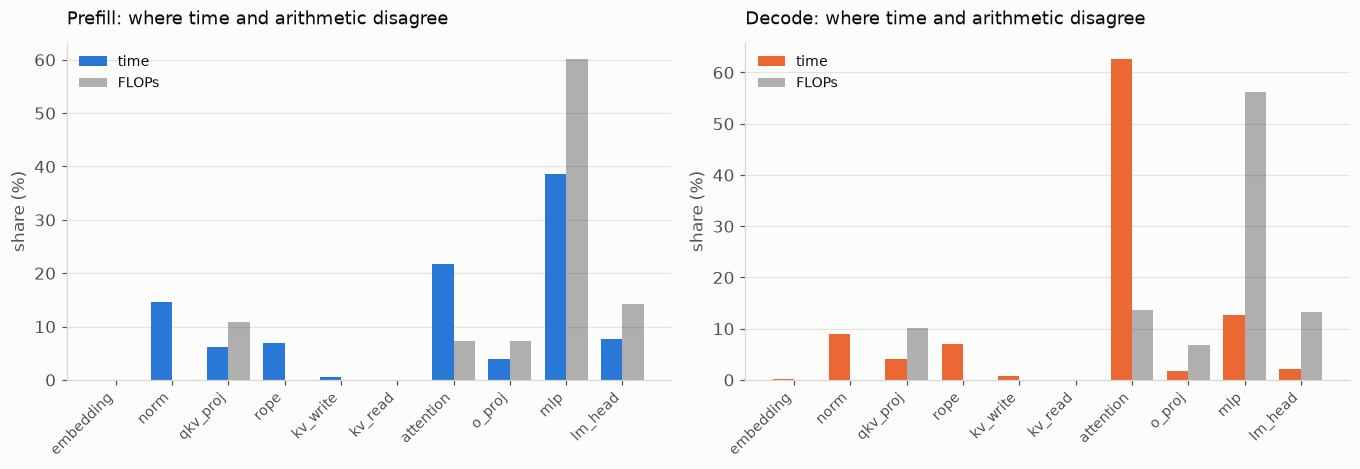

In [7]:
figure, (left, right) = plt.subplots(1, 2, figsize=(12.5, 4.4))
width = 0.38
positions = range(len(ORDER))

for axis, breakdown, flops, total, color, title in (
    (left, PREFILL_BD, PREFILL_FLOPS, PREFILL_TOTAL, PREFILL_COLOR, "Prefill"),
    (right, DECODE_BD, DECODE_FLOPS, DECODE_TOTAL, DECODE_COLOR, "Decode"),
):
    time_share = [breakdown.shares[s] * 100 for s in ORDER]
    flop_share = [flops[s] / total * 100 for s in ORDER]
    axis.bar([p - width / 2 for p in positions], time_share, width, label="time", color=color)
    axis.bar([p + width / 2 for p in positions], flop_share, width, label="FLOPs", color=INK_SOFT, alpha=0.45)
    axis.set_title(f"{title}: where time and arithmetic disagree")
    axis.set_xticks(list(positions))
    axis.set_xticklabels(ORDER, rotation=45, ha="right", fontsize=9)
    axis.set_ylabel("share (%)")
    axis.legend(frameon=False, fontsize=9)
    axis.grid(axis="x", visible=False)

figure.tight_layout()
plt.show()

### 여기서 읽어야 할 것

회색 막대(FLOPs)가 없는데 색 막대(시간)만 솟은 곳을 보세요. **`norm`과 `rope`입니다.**

두 연산의 FLOPs 비중은 정확히 **0%** 입니다. 반올림해서 0이 아니라, 이 모델의 연산량 회계에
잡히지 않을 만큼 작습니다. RMSNorm은 토큰당 몇 번의 곱셈과 한 번의 평균이고,
RoPE는 회전 한 번이죠. 그런데 둘이 합쳐 prefill 시간의 20%, decode 시간의 20%를 씁니다.

**연산이 아닌 것에 시간을 쓰고 있다는 뜻입니다.** 후보는 둘입니다 —
메모리를 읽고 쓰느라, 아니면 커널을 띄우느라. 이 둘은 처방이 완전히 다릅니다.
전자는 kernel fusion으로 줄이고, 후자는 애초에 커널 수를 줄여야 합니다.

`rope`는 후자였습니다. 그것도 아주 고칠 만한 형태로요. §4에서 열어 봅니다.

반대로 **MLP는 FLOPs 비중이 시간 비중보다 큽니다** (ratio < 1). 할 일을 효율적으로 하고 있다는
뜻이고, 이건 좋은 신호입니다. 큰 GEMM은 GPU가 가장 잘하는 일이니까요.
여기서 더 짜내려면 커널이 아니라 **연산량 자체**를 줄여야 합니다 — 양자화나 sparsity처럼요.

## §4. RoPE 사례 연구 — 계측이 찾아낸 두 개의 결함

§3에서 `rope`가 FLOPs 0%에 시간 12%를 쓴다는 걸 봤습니다. 코드를 열어 보면 이유가 나옵니다.

```python
def apply_rope_naive(x, positions):
    head_dim = x.shape[-1]
    inv_freq = 1.0 / (10000 ** (torch.arange(0, head_dim, 2, device=x.device).float() / head_dim))
    angles = torch.outer(positions.float(), inv_freq).to(x.dtype)
    cos, sin = angles.cos()[None, None], angles.sin()[None, None]
    ...
```

`inv_freq`도 `angles`도 `cos`도 `sin`도 **위치에만 의존합니다.** 모델이 사는 동안 절대 변하지 않죠.
그런데 이 함수는 그걸 **매 호출마다 새로 만듭니다.** 레이어 16개 × Q와 K 두 번 =
decode 스텝 하나에 32번. 쓸모없는 커널이 스텝마다 수백 개 발생합니다.

고치는 법은 뻔합니다 — 한 번 만들어 두고 슬라이스만 하면 됩니다.
`infer_opt.model.RotaryEmbedding`이 그것이고, 지금 모델이 쓰는 경로입니다.
아래에서 둘을 나란히 잽니다.

In [8]:
from infer_opt.model import RotaryEmbedding, apply_rope, apply_rope_naive

# 측정 전 클럭을 다시 올린다. 셀 사이의 파이썬 구간 동안 카드는 유휴 클럭으로
# 떨어지고, 그대로 재면 이 셀에서 '첫 번째로 측정한 것'만 몇 배 느리게 나온다.
opp.warmup_device(DEVICE)

ROPE_POSITION = PROMPT_LEN
rope_table = RotaryEmbedding(CFG.head_dim, CFG.max_seq_len)
q_decode = torch.randn(BATCH, CFG.n_heads, 1, CFG.head_dim, device=DEVICE, dtype=DTYPE)
k_decode = torch.randn(BATCH, CFG.n_kv_heads, 1, CFG.head_dim, device=DEVICE, dtype=DTYPE)
positions = torch.arange(ROPE_POSITION, ROPE_POSITION + 1, device=DEVICE)


def naive_step() -> None:
    """decode 스텝 하나가 부르는 만큼: 레이어마다 Q와 K."""
    for _ in range(CFG.n_layers):
        apply_rope_naive(q_decode, positions)
        apply_rope_naive(k_decode, positions)


def table_step() -> None:
    cos, sin = rope_table.slice(ROPE_POSITION, 1, DEVICE)
    for _ in range(CFG.n_layers):
        apply_rope(q_decode, cos, sin)
        apply_rope(k_decode, cos, sin)


naive_timing = prof.timeit(naive_step, device=DEVICE, warmup=5, iters=30)
table_timing = prof.timeit(table_step, device=DEVICE, warmup=5, iters=30)

print(f"  rebuild every call : {naive_timing.ms:7.3f} ms per decode step")
print(f"  precomputed table  : {table_timing.ms:7.3f} ms per decode step")
print(f"  speedup            : {naive_timing.ms / table_timing.ms:7.2f}x")

  rebuild every call :  16.266 ms per decode step
  precomputed table  :   8.242 ms per decode step
  speedup            :    1.97x


2배 가까이 빨라집니다. 연산량은 **한 FLOP도 줄지 않았습니다** — 같은 회전을 같은 횟수만큼 합니다.
줄어든 것은 없어도 되는 커널뿐이죠. §3에서 "FLOPs 0%인데 시간을 쓴다"가 가리킨 게 정확히 이것입니다.

### 그런데 더 나쁜 게 숨어 있었습니다

`angles`를 보세요. `.to(x.dtype)`가 `cos()`와 `sin()` **앞**에 붙어 있습니다.
즉 **각도를 float16으로 반올림한 뒤에** 삼각함수를 취합니다.

float16은 1024 근처에서 표현 간격이 **1.0**입니다. 위치 1024의 가장 낮은 주파수 각도는 1024 rad인데,
이걸 fp16에 넣으면 최대 0.5 rad이 날아갑니다. 0.5 라디안은 29도입니다.

`RotaryEmbedding`은 테이블을 float32로 만들고 **쓰는 순간에만** 캐스팅합니다.
cos와 sin의 값은 -1과 1 사이라 fp16으로도 충분하니까요. 각도가 아니라 결과를 캐스팅하는 것,
그 순서 하나가 차이입니다. float64 기준해와 비교해 봅니다.

In [9]:
def rope_reference(x: torch.Tensor, position: int) -> torch.Tensor:
    """float64로 계산한 정답."""
    head_dim = x.shape[-1]
    steps = torch.arange(0, head_dim, 2, dtype=torch.float64)
    inv_freq = 1.0 / (10000 ** (steps / head_dim))
    angles = torch.outer(torch.tensor([float(position)], dtype=torch.float64), inv_freq)
    cos, sin = angles.cos()[None, None], angles.sin()[None, None]
    wide = x.to(torch.float64)
    even, odd = wide[..., 0::2], wide[..., 1::2]
    return torch.stack((even * cos - odd * sin, even * sin + odd * cos), dim=-1).flatten(-2)


torch.manual_seed(0)
probe = torch.randn(1, 4, 1, CFG.head_dim, dtype=torch.float16)
cpu_table = RotaryEmbedding(CFG.head_dim, CFG.max_seq_len)
POSITIONS = [16, 128, 512, 1024, 2047]
rope_errors = []
for position in POSITIONS:
    exact = rope_reference(probe, position)
    cos, sin = cpu_table.slice(position, 1, torch.device("cpu"))
    naive_err = (apply_rope_naive(probe, torch.tensor([position])).to(torch.float64) - exact).abs().max().item()
    table_err = (apply_rope(probe, cos, sin).to(torch.float64) - exact).abs().max().item()
    rope_errors.append((position, naive_err, table_err))

print(f"{'position':>9} {'naive (fp16 angle)':>20} {'fp32 table':>14} {'factor':>9}")
for position, naive_err, table_err in rope_errors:
    print(f"{position:>9} {naive_err:>20.2e} {table_err:>14.2e} {naive_err / table_err:>8.0f}x")

 position   naive (fp16 angle)     fp32 table    factor
       16             7.09e-03       8.78e-04        8x
      128             5.73e-02       1.97e-03       29x
      512             2.06e-01       1.01e-03      204x
     1024             4.80e-01       1.32e-03      364x
     2047             4.58e-01       1.23e-03      372x


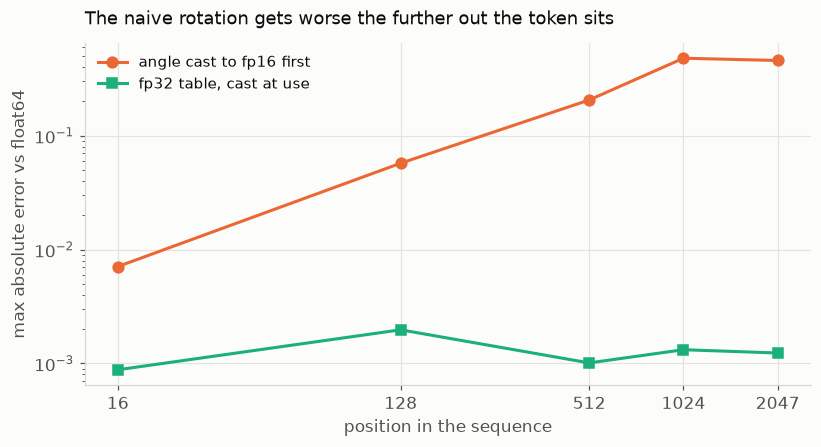

In [10]:
figure, axis = plt.subplots(figsize=(7.6, 4.2))
axis.plot(POSITIONS, [e[1] for e in rope_errors], color=DECODE_COLOR, marker="o", label="angle cast to fp16 first")
axis.plot(POSITIONS, [e[2] for e in rope_errors], color=ACCENT_COLOR, marker="s", label="fp32 table, cast at use")
axis.set_yscale("log"); axis.set_xscale("log", base=2)
axis.set_xticks(POSITIONS); axis.set_xticklabels(POSITIONS)
axis.set_xlabel("position in the sequence"); axis.set_ylabel("max absolute error vs float64")
axis.set_title("The naive rotation gets worse the further out the token sits")
axis.legend(frameon=False, fontsize=9.5)
figure.tight_layout()
plt.show()

### 여기서 읽어야 할 것

오차가 **위치에 비례해 커집니다.** 문맥 앞쪽 토큰은 멀쩡한데 뒤로 갈수록 회전이 틀어지죠.
긴 문맥을 쓰겠다고 `max_seq_len`을 늘릴수록 나빠지는 종류의 버그입니다.

**왜 기존 테스트가 이걸 못 잡았을까요?** `uv run infer-opt check`는
"캐시를 쓴 decode"와 "전체를 한 번에 통과시킨 forward"를 비교합니다.
그런데 두 경로는 **똑같이 틀린 RoPE**를 씁니다. 서로 일치하니 통과하죠.

자기 자신과 비교하는 테스트는 공통 오차를 보지 못합니다. 이 오차는
**바깥의 기준(float64)** 을 가져와야 보입니다. `tests/test_rope.py`가 그 기준을 고정해 둔 이유입니다.

성능을 재려고 열었다가 정확도 버그를 찾았습니다. 프로파일링이 종종 이렇습니다 —
"왜 이게 이렇게 비싸지?"라는 질문이 "애초에 이게 맞나?"로 이어집니다.

## §5. causal mask와 decode attention

§2에서 decode 시간의 절반 이상이 attention이었습니다. 그 안을 봅니다.

causal mask는 **미래를 못 보게** 하는 장치입니다. 위치 $i$의 query는 $j \le i$인 key만 봐야 하죠.
prefill에서는 꼭 필요합니다 — 1024개 query가 한꺼번에 들어오고, 앞쪽 query는
뒤쪽 key를 보면 안 되니까요. 삼각형 마스크가 그 일을 합니다.

**그런데 decode에서는 query가 하나뿐입니다.** 그리고 그 하나는 캐시의 **맨 끝**에 있습니다.
캐시에 들어 있는 모든 key는 이미 그 query의 과거죠.

$$\text{decode: } \; q \text{ at position } T, \quad k_0 \ldots k_T \;\Rightarrow\; \text{모두 허용}$$

**마스크가 전부 True입니다.** 아무것도 가리지 않는 마스크를 만들어서, GPU로 보내고,
원소마다 검사합니다. 그 마스크의 크기는 문맥 길이에 비례해 자라고요.

`infer_opt.strategies`에 세 가지를 등록해 뒀습니다. 차이를 재 봅니다.

- `eager_sdpa` — K/V를 복사해 넓히고, 마스크를 만들어 넘긴다 (1장부터의 기준선)
- `gqa_native` — 마스크는 만들되 K/V 복사를 커널에 맡긴다 (`enable_gqa=True`)
- `decode_nomask` — 마스크를 아예 만들지 않는다 (query가 하나일 때만 유효)

In [11]:
from infer_opt.strategies import causal_mask, expand_kv, make_attention_strategy

# 측정 전 클럭을 다시 올린다. 셀 사이의 파이썬 구간 동안 카드는 유휴 클럭으로
# 떨어지고, 그대로 재면 이 셀에서 '첫 번째로 측정한 것'만 몇 배 느리게 나온다.
opp.warmup_device(DEVICE)

CONTEXT = PROMPT_LEN + 1
q_attn = torch.randn(BATCH, CFG.n_heads, 1, CFG.head_dim, device=DEVICE, dtype=DTYPE)
k_attn = torch.randn(BATCH, CFG.n_kv_heads, CONTEXT, CFG.head_dim, device=DEVICE, dtype=DTYPE)
v_attn = torch.randn_like(k_attn)

mask = causal_mask(q_attn, k_attn, query_start=PROMPT_LEN)
print(f"decode 의 causal mask: shape {tuple(mask.shape)}, True 비율 {mask.float().mean():.1%}")
print(f"  -> {mask.numel()} 개 원소를 만들어 전부 통과시킨다\n")

MASK_VARIANTS = ["eager_sdpa", "gqa_native", "decode_nomask"]
baseline = make_attention_strategy("eager_sdpa")(q_attn, k_attn, v_attn, query_start=PROMPT_LEN)
mask_rows = []
for name in MASK_VARIANTS:
    strategy = make_attention_strategy(name)
    output = strategy(q_attn, k_attn, v_attn, query_start=PROMPT_LEN)
    timing = prof.timeit(lambda s=strategy: s(q_attn, k_attn, v_attn, query_start=PROMPT_LEN),
                         device=DEVICE, warmup=10, iters=50)
    mask_rows.append({"name": name, "ms": timing.ms,
                      "diff": (output - baseline).abs().max().item()})

print(f"{'strategy':>16} {'ms':>9} {'vs eager':>10} {'max |diff|':>12}")
for row in mask_rows:
    print(f"{row['name']:>16} {row['ms']:>9.4f} {mask_rows[0]['ms'] / row['ms']:>9.2f}x {row['diff']:>12.1e}")

decode 의 causal mask: shape (1, 1025), True 비율 100.0%
  -> 1025 개 원소를 만들어 전부 통과시킨다

        strategy        ms   vs eager   max |diff|
      eager_sdpa    0.8185      1.00x      0.0e+00
      gqa_native    0.7863      1.04x      0.0e+00
   decode_nomask    0.2568      3.19x      0.0e+00


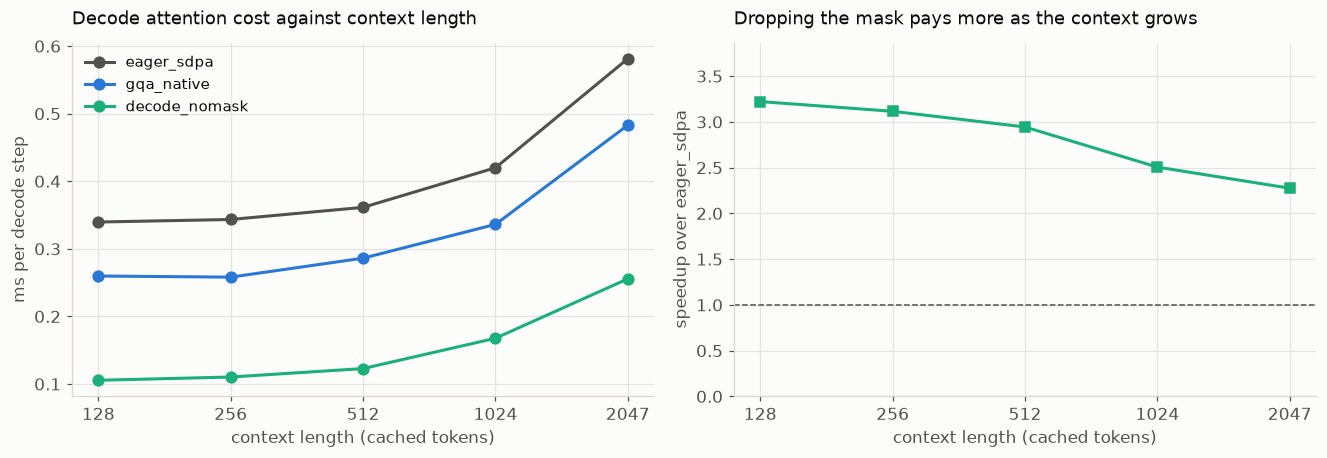

In [12]:
# 측정 전 클럭을 다시 올린다. 셀 사이의 파이썬 구간 동안 카드는 유휴 클럭으로
# 떨어지고, 그대로 재면 이 셀에서 '첫 번째로 측정한 것'만 몇 배 느리게 나온다.
opp.warmup_device(DEVICE)

CONTEXTS = [128, 256, 512, 1024, 2047]
scaling = {name: [] for name in MASK_VARIANTS}
for context in CONTEXTS:
    key = torch.randn(BATCH, CFG.n_kv_heads, context, CFG.head_dim, device=DEVICE, dtype=DTYPE)
    value = torch.randn_like(key)
    start = context - 1
    for name in MASK_VARIANTS:
        strategy = make_attention_strategy(name)
        timing = prof.timeit(lambda s=strategy, k=key, v=value, st=start: s(q_attn, k, v, query_start=st),
                             device=DEVICE, warmup=5, iters=30)
        scaling[name].append(timing.ms)
    del key, value
torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

figure, (left, right) = plt.subplots(1, 2, figsize=(12.2, 4.3))
COLORS = {"eager_sdpa": INK_SOFT, "gqa_native": PREFILL_COLOR, "decode_nomask": ACCENT_COLOR}
for name in MASK_VARIANTS:
    left.plot(CONTEXTS, scaling[name], marker="o", color=COLORS[name], label=name)
left.set_title("Decode attention cost against context length")
left.set_xlabel("context length (cached tokens)"); left.set_ylabel("ms per decode step")
left.set_xscale("log", base=2); left.set_xticks(CONTEXTS); left.set_xticklabels(CONTEXTS)
left.legend(frameon=False, fontsize=9.5)

speedup = [scaling["eager_sdpa"][i] / scaling["decode_nomask"][i] for i in range(len(CONTEXTS))]
right.plot(CONTEXTS, speedup, marker="s", color=ACCENT_COLOR)
right.axhline(1.0, color=INK_SOFT, linewidth=1, linestyle="--")
right.set_title("Dropping the mask pays more as the context grows")
right.set_xlabel("context length (cached tokens)"); right.set_ylabel("speedup over eager_sdpa")
right.set_xscale("log", base=2); right.set_xticks(CONTEXTS); right.set_xticklabels(CONTEXTS)
right.set_ylim(0, max(speedup) * 1.2)
figure.tight_layout()
plt.show()

### 여기서 읽어야 할 것

**마스크를 버리는 것만으로 decode attention이 크게 빨라집니다.** 수치는 완전히 동일합니다
(`max |diff|`가 0이죠) — 아무것도 가리지 않던 마스크를 안 만들었을 뿐이니까요.

**그리고 이득이 문맥 길이에 따라 커집니다.** 당연합니다. 마스크는 `[1, context]` 크기라
문맥이 길수록 만들고 옮기고 검사할 원소가 늘어납니다. 문맥 2048에서 낭비되는 일이
문맥 128에서보다 16배 많죠. **긴 문맥 서빙일수록 이 낭비가 커집니다.**

`gqa_native`도 공짜로 조금 얻습니다. K/V를 4배로 복사해서 넘기던 것을
커널이 제자리에서 읽게 하면, 그 복사에 쓰던 대역폭이 그대로 절약됩니다.

**이 절의 교훈은 커널이 아니라 관점입니다.** decode attention은 prefill attention의
축소판이 아닙니다. query가 하나라는 사실이 마스크를 통째로 불필요하게 만들고,
그러면 그건 **다른 연산**입니다. 실제 추론 엔진들이 prefill 커널과 decode 커널을
따로 두는 이유가 이것입니다.

## §6. MHA / MQA / GQA

§2에서 decode attention이 1위였고, §5에서 마스크를 걷어냈습니다. 그래도 남는 비용이 있습니다 —
**KV 캐시를 읽는 일** 자체입니다. 그건 커널을 아무리 잘 짜도 없앨 수 없습니다.
읽어야 할 바이트 수를 줄이지 않는 한요.

그 바이트 수를 정하는 것이 **K/V head의 개수**입니다. 세 가지 선택지가 있습니다.

| | K/V head 수 | 캐시 크기 | 품질 |
|---|---|---|---|
| **MHA** (Multi-Head) | query head와 동일 | 가장 큼 | 기준 |
| **GQA** (Grouped-Query) | query head의 1/g | 1/g | 거의 유지 |
| **MQA** (Multi-Query) | 1개 | 가장 작음 | 약간 손해 |

핵심은 **query head는 그대로 두고 K/V head만 줄인다**는 점입니다. 16개 query head가
4개 K/V head를 나눠 쓰면(GQA 16:4), head당 표현력은 유지하면서 캐시는 1/4이 됩니다.

`ModelConfig`가 이미 `n_kv_heads`로 셋을 전부 표현합니다. 숫자만 바꿔 비교합니다.

In [13]:
VARIANTS = [("MHA", 16), ("GQA", 4), ("MQA", 1)]
CONTEXT_FOR_KV = 2048

variant_rows = []
for label, n_kv_heads in VARIANTS:
    config = ModelConfig(
        vocab_size=CFG.vocab_size, hidden_size=CFG.hidden_size, n_layers=CFG.n_layers,
        n_heads=CFG.n_heads, n_kv_heads=n_kv_heads,
        intermediate_size=CFG.intermediate_size, max_seq_len=CFG.max_seq_len,
    )
    kv = prof.kv_cache_bytes(config, batch=BATCH, context_len=CONTEXT_FOR_KV, dtype=DTYPE)
    workload = prof.step_workload(config, batch=BATCH, new_tokens=1, context_len=CONTEXT_FOR_KV, dtype=DTYPE)
    variant_rows.append({
        "label": label, "n_kv_heads": n_kv_heads, "config": config,
        "params": prof.parameter_count(config),
        "weights": prof.parameter_bytes(config, DTYPE),
        "kv": kv,
        "ai": workload.arithmetic_intensity,
    })

print(f"{'':>5} {'n_kv':>5} {'params':>10} {'weights':>11} {'KV cache':>12} {'decode AI':>11}")
for row in variant_rows:
    print(f"{row['label']:>5} {row['n_kv_heads']:>5} {row['params'] / 1e6:>9.1f}M "
          f"{row['weights'] / 1e6:>10.1f}MB {row['kv'] / 1e6:>11.1f}MB {row['ai']:>11.2f}")
print(f"\n(batch {BATCH}, context {CONTEXT_FOR_KV}, {RUN.dtype})")
print(f"MHA -> MQA : 가중치 {variant_rows[0]['weights'] / variant_rows[2]['weights']:.2f}x 감소, "
      f"KV 캐시 {variant_rows[0]['kv'] / variant_rows[2]['kv']:.0f}x 감소")
peak_gbps_hint = prof.measure_peak_bandwidth(DEVICE, DTYPE)

       n_kv     params     weights     KV cache   decode AI
  MHA    16     271.1M      542.2MB      1073.7MB        3.01
  GQA     4     245.9M      491.8MB       268.4MB        5.83
  MQA     1     239.6M      479.3MB        67.1MB        7.90

(batch 8, context 2048, float16)
MHA -> MQA : 가중치 1.13x 감소, KV 캐시 16x 감소


In [14]:
# 측정 전 클럭을 다시 올린다. 셀 사이의 파이썬 구간 동안 카드는 유휴 클럭으로
# 떨어지고, 그대로 재면 이 셀에서 '첫 번째로 측정한 것'만 몇 배 느리게 나온다.
opp.warmup_device(DEVICE)


@torch.inference_mode()
def decode_attention_ms(n_kv_heads: int, batch: int, context: int) -> tuple[float, float]:
    """decode attention 한 번의 시간과, 그때 읽은 KV 바이트."""
    query = torch.randn(batch, CFG.n_heads, 1, CFG.head_dim, device=DEVICE, dtype=DTYPE)
    key = torch.randn(batch, n_kv_heads, context, CFG.head_dim, device=DEVICE, dtype=DTYPE)
    value = torch.randn_like(key)
    strategy = make_attention_strategy("decode_nomask")
    timing = prof.timeit(lambda: strategy(query, key, value, query_start=context - 1),
                         device=DEVICE, warmup=10, iters=40)
    kv_bytes = 2 * batch * n_kv_heads * context * CFG.head_dim * key.element_size()
    del query, key, value
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return timing.ms, kv_bytes


SWEEP_BATCHES = [8, 32, 64, 128]
sweep = {label: [] for label, _ in VARIANTS}
sweep_bytes = {label: [] for label, _ in VARIANTS}
for batch in SWEEP_BATCHES:
    for label, n_kv_heads in VARIANTS:
        ms, kv_bytes = decode_attention_ms(n_kv_heads, batch, CONTEXT_FOR_KV)
        sweep[label].append(ms)
        sweep_bytes[label].append(kv_bytes)

print(f"decode attention, one layer, context {CONTEXT_FOR_KV}\n")
print(f"{'batch':>6} {'MHA ms':>9} {'GQA ms':>9} {'MQA ms':>9} {'MHA/MQA':>9} "
      f"{'MHA GB/s':>10} {'MQA GB/s':>10}")
for index, batch in enumerate(SWEEP_BATCHES):
    mha, gqa, mqa = (sweep[label][index] for label, _ in VARIANTS)
    mha_gbps = sweep_bytes["MHA"][index] / (mha / 1000) / 1e9
    mqa_gbps = sweep_bytes["MQA"][index] / (mqa / 1000) / 1e9
    print(f"{batch:>6} {mha:>9.4f} {gqa:>9.4f} {mqa:>9.4f} {mha / mqa:>8.2f}x "
          f"{mha_gbps:>10.0f} {mqa_gbps:>10.0f}")
print(f"\n이 장치의 실측 피크 대역폭: {peak_gbps_hint:.0f} GB/s")

decode attention, one layer, context 2048

 batch    MHA ms    GQA ms    MQA ms   MHA/MQA   MHA GB/s   MQA GB/s
     8    0.2652    0.2596    0.2577     1.03x        253         16
    32    0.7852    0.7486    0.7407     1.06x        342         23
    64    1.4477    1.3948    1.3835     1.05x        371         24
   128    2.7856    2.6169    2.5650     1.09x        385         26

이 장치의 실측 피크 대역폭: 420 GB/s


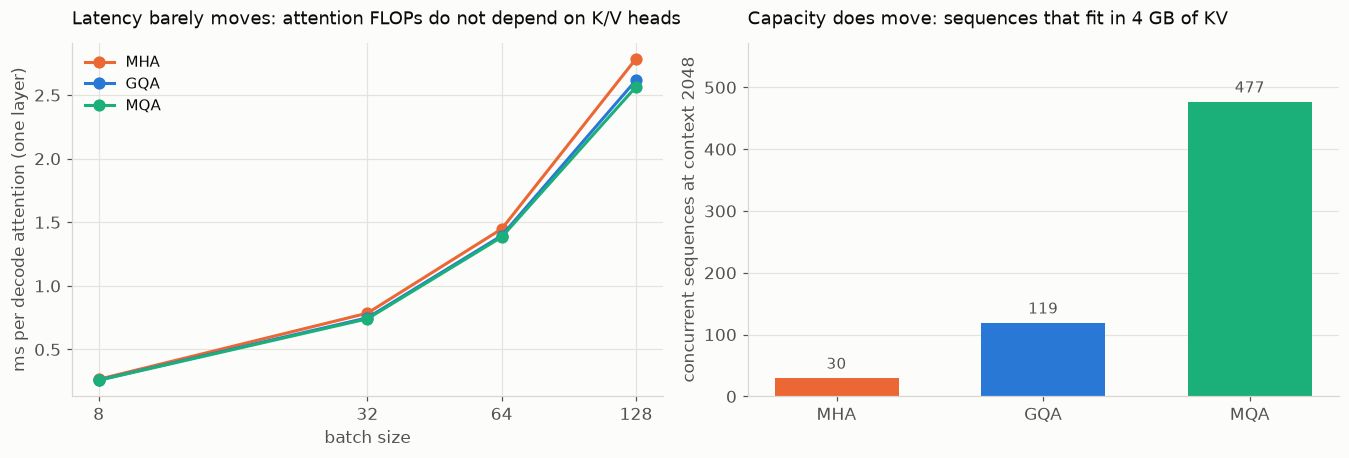

4 GB 의 KV 예산으로 받을 수 있는 동시 시퀀스 (context 2048):
   MHA     30 개
   GQA    119 개
   MQA    477 개


In [15]:
figure, (left, right) = plt.subplots(1, 2, figsize=(12.4, 4.3))
variant_colors = {"MHA": DECODE_COLOR, "GQA": PREFILL_COLOR, "MQA": ACCENT_COLOR}

for label, _ in VARIANTS:
    left.plot(SWEEP_BATCHES, sweep[label], marker="o", color=variant_colors[label], label=label)
left.set_title("Latency barely moves: attention FLOPs do not depend on K/V heads")
left.set_xlabel("batch size"); left.set_ylabel("ms per decode attention (one layer)")
left.set_xscale("log", base=2); left.set_xticks(SWEEP_BATCHES); left.set_xticklabels(SWEEP_BATCHES)
left.legend(frameon=False, fontsize=9.5)

budget_gb = 4.0
budget = budget_gb * 1e9
seats = [budget / prof.kv_cache_bytes(row["config"], batch=1, context_len=CONTEXT_FOR_KV, dtype=DTYPE)
         for row in variant_rows]
bars = right.bar([r["label"] for r in variant_rows], seats,
                 color=[variant_colors[r["label"]] for r in variant_rows], width=0.6)
right.set_title(f"Capacity does move: sequences that fit in {budget_gb:.0f} GB of KV")
right.set_ylabel(f"concurrent sequences at context {CONTEXT_FOR_KV}")
for bar, seat in zip(bars, seats):
    right.annotate(f"{seat:.0f}", (bar.get_x() + bar.get_width() / 2, seat),
                   textcoords="offset points", xytext=(0, 6), ha="center",
                   color=INK_SOFT, fontsize=9.5)
right.set_ylim(0, max(seats) * 1.2)
right.grid(axis="x", visible=False)

figure.tight_layout()
plt.show()

print(f"{budget_gb:.0f} GB 의 KV 예산으로 받을 수 있는 동시 시퀀스 (context {CONTEXT_FOR_KV}):")
for row, seat in zip(variant_rows, seats):
    print(f"  {row['label']:>4} {seat:>6.0f} 개")

### 여기서 읽어야 할 것

**지연은 거의 움직이지 않았습니다.** 이건 실망이 아니라 정보입니다 — 그리고 이유가 분명합니다.

GQA는 **읽는 바이트를 줄이지, 연산을 줄이지 않습니다.** query head는 여전히 16개이고,
각각이 여전히 2048개 key 전부와 내적을 합니다. attention의 FLOPs는
`n_kv_heads`와 **무관**합니다. K/V head가 하나뿐이면 그 하나를 16번 재사용할 뿐이죠.

$$\text{FLOPs} \propto n_{\text{heads}} \times T \qquad\qquad \text{Bytes} \propto n_{\text{kv\_heads}} \times T$$

**GB/s 열이 그 증거입니다.** batch 128에서 MHA는 이 카드 실측 피크의 90% 넘게 씁니다 —
진짜로 대역폭에 막혀 있죠. 그런데 MQA는 같은 시간을 쓰면서 피크의 몇 퍼센트밖에 못 씁니다.
읽을 것이 16분의 1로 줄었는데 시간이 그대로라는 건, **MQA의 병목이 더 이상 읽기가 아니라는 뜻**입니다.
줄지 않은 쪽 — 연산과 커널 실행 — 이 바닥을 만들고 있습니다.

**그럼 GQA는 무엇을 사는가 — 용량입니다.** 오른쪽 그래프가 그것입니다.
같은 메모리 예산으로 MQA는 MHA보다 16배 많은 시퀀스를 얹을 수 있습니다.

그리고 **그 용량이 결국 처리량이 됩니다.** 1장에서 배웠듯 decode는 배칭이 거의 공짜인 구간입니다.
캐시가 16분의 1이면 batch를 훨씬 크게 잡을 수 있고, 큰 batch가 곧 높은 처리량이죠.
GQA의 이득은 **한 스텝을 빠르게 하는 것이 아니라, 한 스텝에 더 많은 요청을 태우는 것**입니다.

이것이 "무엇을 최적화하는가"를 정확히 말해야 하는 이유입니다.
"GQA가 decode를 빠르게 한다"는 문장은 이 측정 앞에서 틀렸습니다.
"GQA는 KV 캐시를 줄여 더 큰 배치를 가능하게 하고, 그래서 처리량을 올린다"가 맞습니다.

**대신 품질은 공짜가 아닙니다.** MQA는 모든 query head가 K/V 하나를 공유하니
head마다 다른 것을 보는 능력이 줄어듭니다. GQA는 그 사이의 타협이고,
대부분의 최신 모델이 4에서 8 사이의 `n_kv_heads`를 쓰는 이유입니다.
(이 노트북의 모델은 무작위 가중치라 품질은 잴 수 없습니다 — 비용만 잽니다.)

## §7. FlashAttention

지금까지는 attention을 **블랙박스**로 두고 입출력만 봤습니다. 안을 엽니다.

교과서적인 attention은 이렇습니다.

$$S = \frac{QK^\top}{\sqrt{d}} \qquad P = \text{softmax}(S) \qquad O = PV$$

문제는 $S$입니다. query $T$개와 key $T$개면 $S$는 $T \times T$입니다.
$T = 4096$이면 head 하나당 1600만 개, head 16개면 **2억 6천만 개**의 숫자를
메모리에 썼다가 다시 읽습니다. 그리고 그 대부분은 softmax를 통과한 직후 버려집니다.

**FlashAttention의 발상은 $S$를 아예 만들지 않는 것입니다.** key를 블록으로 잘라,
블록 하나를 처리할 때마다 softmax의 최댓값과 합을 **누적해 가며** 출력을 갱신합니다
(online softmax). 각 블록의 $S$ 조각은 레지스터와 SRAM 안에서 생겼다가 사라지고,
HBM에는 최종 출력만 남죠.

$$\text{메모리: } O(T^2) \;\longrightarrow\; O(T)$$

연산량은 똑같습니다. 줄어드는 건 **메모리 이동**뿐입니다. 그런데 1장이 가르쳤듯,
attention은 메모리 이동이 병목입니다. 그래서 같은 FLOPs가 몇 배 빨라집니다.

### 이 GPU의 한계를 먼저 말해 둡니다

PyTorch의 진짜 FlashAttention 백엔드(`SDPBackend.FLASH_ATTENTION`)는 **sm80 이상**을 요구합니다.
이 노트북이 도는 카드가 그보다 낮다면 그 백엔드는 쓸 수 없습니다.

대신 **mem-efficient 백엔드**가 있습니다. 구현은 다르지만(cutlass) 발상은 같은 계열입니다 —
타일링, online softmax, $N \times N$ 미실체화. 그래서 **메모리 주장은 그대로 재현됩니다.**
아래 표가 그 증거입니다. 아래에서 실제로 어떤 백엔드가 쓸 수 있는지부터 확인합니다.

In [16]:
import warnings

import torch.nn.functional as F
from torch.nn.attention import SDPBackend, sdpa_kernel

probe_q = torch.randn(1, 8, 256, 64, device=DEVICE, dtype=DTYPE)
probe_k = torch.randn_like(probe_q)
print(f"compute capability: {INFO.get('compute_capability', 'n/a')}\n")
AVAILABLE = {}
for backend in (SDPBackend.FLASH_ATTENTION, SDPBackend.EFFICIENT_ATTENTION,
                SDPBackend.CUDNN_ATTENTION, SDPBackend.MATH):
    try:
        # 거절당한 백엔드마다 PyTorch 가 이유를 경고로 쏟아낸다.
        # 아래 표가 같은 내용을 요약하므로 여기서는 삼킨다.
        with warnings.catch_warnings(), sdpa_kernel(backend):
            warnings.simplefilter("ignore")
            F.scaled_dot_product_attention(probe_q, probe_k, probe_k, is_causal=True)
        synchronize(DEVICE)
        AVAILABLE[backend.name] = True
    except Exception:
        AVAILABLE[backend.name] = False
    print(f"  {backend.name:<20} {'available' if AVAILABLE[backend.name] else 'NOT available on this GPU'}")
del probe_q, probe_k
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

compute capability: 7.5

  FLASH_ATTENTION      NOT available on this GPU
  EFFICIENT_ATTENTION  available
  CUDNN_ATTENTION      NOT available on this GPU


  MATH                 available


In [17]:
# 측정 전 클럭을 다시 올린다. 셀 사이의 파이썬 구간 동안 카드는 유휴 클럭으로
# 떨어지고, 그대로 재면 이 셀에서 '첫 번째로 측정한 것'만 몇 배 느리게 나온다.
opp.warmup_device(DEVICE)

@torch.inference_mode()
def attention_cost(backend: SDPBackend, seq_len: int, heads: int = 16, head_dim: int = 64) -> tuple[float, float]:
    """prefill attention 한 번의 peak 메모리(MB)와 시간(ms)."""
    query = torch.randn(1, heads, seq_len, head_dim, device=DEVICE, dtype=DTYPE)
    key, value = torch.randn_like(query), torch.randn_like(query)
    synchronize(DEVICE)
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    baseline = torch.cuda.memory_allocated() if DEVICE.type == "cuda" else 0
    with sdpa_kernel(backend):
        output = F.scaled_dot_product_attention(query, key, value, is_causal=True)
        synchronize(DEVICE)
        peak = (torch.cuda.max_memory_allocated() - baseline) if DEVICE.type == "cuda" else 0
        del output
        timing = prof.timeit(
            lambda: F.scaled_dot_product_attention(query, key, value, is_causal=True),
            device=DEVICE, warmup=3, iters=10,
        )
    del query, key, value
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return peak / 1e6, timing.ms


# T=4096 의 MATH 백엔드가 2.5 GB 가까이 쓰므로 여기서 끊는다.
SEQ_LENS = [512, 1024, 2048, 4096]
TILED = "EFFICIENT_ATTENTION" if AVAILABLE.get("EFFICIENT_ATTENTION") else "FLASH_ATTENTION"
TILED_BACKEND = getattr(SDPBackend, TILED)

flash_rows = []
for seq_len in SEQ_LENS:
    math_mb, math_ms = attention_cost(SDPBackend.MATH, seq_len)
    tiled_mb, tiled_ms = attention_cost(TILED_BACKEND, seq_len)
    flash_rows.append({"T": seq_len, "math_mb": math_mb, "tiled_mb": tiled_mb,
                       "math_ms": math_ms, "tiled_ms": tiled_ms})

print(f"unfused = MATH, tiled = {TILED}\n")
print(f"{'T':>6} {'unfused MB':>12} {'tiled MB':>10} {'memory':>9}   {'unfused ms':>11} {'tiled ms':>9} {'speed':>8}")
for row in flash_rows:
    print(f"{row['T']:>6} {row['math_mb']:>12.1f} {row['tiled_mb']:>10.1f} {row['math_mb'] / row['tiled_mb']:>8.0f}x   "
          f"{row['math_ms']:>11.3f} {row['tiled_ms']:>9.3f} {row['math_ms'] / row['tiled_ms']:>7.1f}x")

unfused = MATH, tiled = EFFICIENT_ATTENTION

     T   unfused MB   tiled MB    memory    unfused ms  tiled ms    speed
   512         47.2        1.0       45x         0.817     0.118     6.9x
  1024        172.0        2.1       82x         2.587     0.205    12.6x
  2048        654.3        4.2      156x         9.775     0.494    19.8x
  4096       2550.2        8.4      304x        35.522     1.577    22.5x


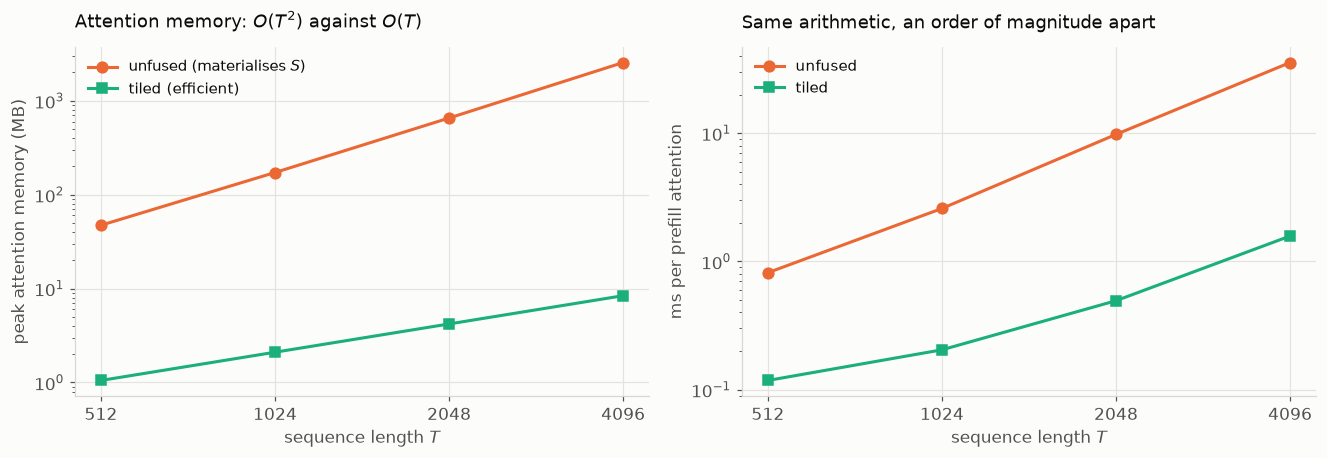

In [18]:
figure, (left, right) = plt.subplots(1, 2, figsize=(12.2, 4.3))
lengths = [r["T"] for r in flash_rows]

left.plot(lengths, [r["math_mb"] for r in flash_rows], marker="o", color=DECODE_COLOR,
          label="unfused (materialises $S$)")
left.plot(lengths, [r["tiled_mb"] for r in flash_rows], marker="s", color=ACCENT_COLOR,
          label=f"tiled ({TILED.split('_')[0].lower()})")
left.set_yscale("log"); left.set_xscale("log", base=2)
left.set_xticks(lengths); left.set_xticklabels(lengths)
left.set_title(r"Attention memory: $O(T^2)$ against $O(T)$")
left.set_xlabel("sequence length $T$"); left.set_ylabel("peak attention memory (MB)")
left.legend(frameon=False, fontsize=9.5)

right.plot(lengths, [r["math_ms"] for r in flash_rows], marker="o", color=DECODE_COLOR, label="unfused")
right.plot(lengths, [r["tiled_ms"] for r in flash_rows], marker="s", color=ACCENT_COLOR, label="tiled")
right.set_yscale("log"); right.set_xscale("log", base=2)
right.set_xticks(lengths); right.set_xticklabels(lengths)
right.set_title("Same arithmetic, an order of magnitude apart")
right.set_xlabel("sequence length $T$"); right.set_ylabel("ms per prefill attention")
right.legend(frameon=False, fontsize=9.5)

figure.tight_layout()
plt.show()

### 여기서 읽어야 할 것

**메모리 곡선의 기울기가 다릅니다.** 왼쪽 그래프는 로그-로그입니다.
unfused는 $T$가 2배가 될 때 4배로 뛰고(기울기 2), tiled는 2배로 늘어납니다(기울기 1).
$O(T^2)$와 $O(T)$가 눈으로 보이는 형태죠.

**그 차이가 곧 한계 문맥 길이입니다.** unfused 경로는 $T = 4096$에서 이미 기가바이트 단위를
요구합니다. 여기에 batch를 곱하면 금방 카드가 넘치죠. tiled 경로는 같은 자리에서 메가바이트 단위입니다.
"긴 문맥을 지원한다"는 말의 상당 부분은 사실 **이 커널을 쓴다**는 뜻입니다.

**연산량은 하나도 줄지 않았는데 시간이 배수로 줄었습니다.** 두 경로는 완전히 같은 FLOPs를 합니다.
차이는 HBM을 몇 번 왕복하느냐뿐이죠. 1장의 결론 — attention은 memory-bound —
이 없으면 이 결과는 설명이 안 됩니다.

**한계도 분명히.** 위에서 확인했듯 이 카드에서 진짜 FlashAttention-2 커널은 돌지 않습니다.
여기 "tiled"는 같은 계열의 다른 구현입니다. 최신 카드에서는 숫자가 더 벌어지지,
좁혀지지 않습니다 — 방향이 바뀌지는 않습니다.

## §8. KV cache layout

§2에서 `kv_read`가 0 ms로 찍힌 걸 기억하시나요. `KVCache.read()`가 슬라이스라서 그랬습니다.
그럼 진짜 읽기 비용은 어디 있을까요 — attention 커널 안입니다.
그리고 그 비용은 **캐시가 메모리에 어떻게 놓였는지**에 달려 있습니다.

이 저장소의 캐시는 이렇게 생겼습니다.

```
keys: (n_layers, batch, n_kv_heads, max_seq_len, head_dim)
```

`max_seq_len`이 뒤에서 두 번째입니다. 즉 **한 head의 시퀀스가 연속**으로 놓입니다(head-major).
대안은 시퀀스를 앞에 두는 것이죠(seq-major): `(batch, max_seq_len, n_kv_heads, head_dim)`.
한 위치의 모든 head가 연속으로 놓입니다.

어느 쪽이 빠를까요? 직관은 "연속이 좋다"지만, 실제로 무엇이 비용인지 재 봅니다.

In [19]:
# 측정 전 클럭을 다시 올린다. 셀 사이의 파이썬 구간 동안 카드는 유휴 클럭으로
# 떨어지고, 그대로 재면 이 셀에서 '첫 번째로 측정한 것'만 몇 배 느리게 나온다.
opp.warmup_device(DEVICE)

@torch.inference_mode()
def layout_cost(context: int) -> dict[str, float]:
    heads, kv_heads, dim = CFG.n_heads, CFG.n_kv_heads, CFG.head_dim
    query = torch.randn(BATCH, heads, 1, dim, device=DEVICE, dtype=DTYPE)
    head_major = torch.randn(BATCH, kv_heads, context, dim, device=DEVICE, dtype=DTYPE)
    seq_major = torch.randn(BATCH, context, kv_heads, dim, device=DEVICE, dtype=DTYPE)
    as_view = seq_major.permute(0, 2, 1, 3)
    materialised = as_view.contiguous()

    def run(key):
        return F.scaled_dot_product_attention(query, key, key, enable_gqa=True)

    results = {
        "head-major (this repo)": prof.timeit(lambda: run(head_major), device=DEVICE, warmup=10, iters=40).ms,
        "seq-major, permuted view": prof.timeit(lambda: run(as_view), device=DEVICE, warmup=10, iters=40).ms,
        "seq-major + .contiguous()": prof.timeit(
            lambda: run(as_view.contiguous()), device=DEVICE, warmup=10, iters=40).ms,
        "already materialised": prof.timeit(lambda: run(materialised), device=DEVICE, warmup=10, iters=40).ms,
    }
    kv_bytes = 2 * BATCH * kv_heads * context * dim * head_major.element_size()
    del query, head_major, seq_major, as_view, materialised
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return results, kv_bytes


LAYOUT_CONTEXT = 2048
layout_results, layout_bytes = layout_cost(LAYOUT_CONTEXT)
peak_gbps = prof.measure_peak_bandwidth(DEVICE, DTYPE)

print(f"one layer's decode read, batch {BATCH}, context {LAYOUT_CONTEXT}")
print(f"KV bytes touched: {layout_bytes / 1e6:.1f} MB\n")
print(f"{'layout':>28} {'ms':>9} {'GB/s':>9} {'% of peak':>11}")
for name, ms in layout_results.items():
    achieved = layout_bytes / (ms / 1000) / 1e9
    print(f"{name:>28} {ms:>9.4f} {achieved:>9.0f} {achieved / peak_gbps:>10.0%}")
print(f"\nmeasured peak bandwidth on this device: {peak_gbps:.0f} GB/s")

one layer's decode read, batch 8, context 2048
KV bytes touched: 16.8 MB

                      layout        ms      GB/s   % of peak
      head-major (this repo)    0.2498        67        16%
    seq-major, permuted view    0.2476        68        16%
   seq-major + .contiguous()    0.2733        61        15%
        already materialised    0.2476        68        16%

measured peak bandwidth on this device: 420 GB/s


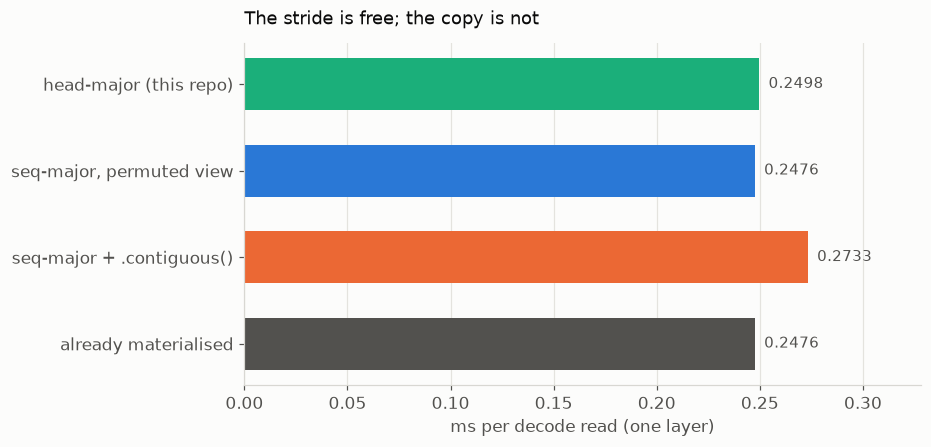

In [20]:
figure, axis = plt.subplots(figsize=(8.6, 4.2))
names = list(layout_results)
values = [layout_results[n] for n in names]
colors = [ACCENT_COLOR, PREFILL_COLOR, DECODE_COLOR, INK_SOFT]
bars = axis.barh(names, values, color=colors, height=0.6)
axis.invert_yaxis()
axis.set_xlabel("ms per decode read (one layer)")
axis.set_title("The stride is free; the copy is not")
for bar, value in zip(bars, values):
    axis.annotate(f"{value:.4f}", (value, bar.get_y() + bar.get_height() / 2),
                  textcoords="offset points", xytext=(6, 0), va="center", color=INK_SOFT, fontsize=9.5)
axis.set_xlim(0, max(values) * 1.2)
axis.grid(axis="y", visible=False)
figure.tight_layout()
plt.show()

### 여기서 읽어야 할 것

**직관이 반쯤 틀렸습니다.** seq-major를 permute한 view는 head-major와 거의 같은 속도입니다.
텐서가 "연속이 아니어서" 느려지지 않았죠 — **커널이 stride를 감당합니다.**
요즘 attention 커널은 임의의 stride로 K/V를 읽도록 짜여 있으니까요.

**비싼 것은 `.contiguous()` 입니다.** 레이아웃을 맞추겠다고 복사를 한 번 넣으면
그게 곧 비용입니다. 읽을 바이트를 한 번 더 읽고 한 번 더 쓰는 거죠.

교훈: **레이아웃 자체가 아니라 레이아웃을 바꾸느라 생기는 복사를 피해야 합니다.**
캐시를 설계할 때 물어야 할 질문은 "무엇이 연속인가"가 아니라
"이 모양을 커널에 그대로 먹일 수 있는가"입니다.

**달성 대역폭도 보세요.** 이 카드의 실측 피크에 한참 못 미칩니다.
decode attention은 **아직 대역폭 포화 상태도 아니라는 뜻입니다** — batch 8, 한 레이어의
읽기는 GPU를 다 쓰기엔 너무 작은 일입니다. 여기서 더 가려면 배치를 키우거나
(§9의 연속 배칭), 레이어를 가로질러 일을 뭉쳐야 합니다.

그리고 이 사실이 다음 절로 이어집니다. **KV를 블록으로 쪼개 흩어 놓아도**
커널이 stride와 인덱스를 감당한다면 큰 손해가 아니라는 것 — PagedAttention이 성립하는 전제입니다.

## §9. PagedAttention

이제 서빙 이야기입니다.

`KVCache`는 만들어질 때 `max_seq_len`만큼의 자리를 **미리 잡습니다.**
2048 토큰까지 받겠다고 하면, 시퀀스마다 2048칸을 잡아 둡니다.
그런데 실제 요청이 300 토큰에서 끝나면? **1748칸이 놉니다.**
누수가 아니라, 아무도 찾아가지 않은 약속이죠.

$$\text{낭비율} = 1 - \frac{\text{실제 길이}}{\text{max\_seq\_len}}$$

이게 심각한 이유는 KV 캐시가 **서빙 동시성을 직접 결정**하기 때문입니다.
GPU 메모리에 캐시가 몇 개 들어가느냐가 곧 동시에 처리할 수 있는 요청 수입니다.
80%를 낭비하면 동시 처리량도 5분의 1이 됩니다.

**PagedAttention의 해법은 운영체제의 가상 메모리와 같습니다.** 캐시를 고정 크기 **블록**으로 쪼개고,
시퀀스마다 "내 블록이 어디 있는지"를 적은 **block table**을 둡니다.
시퀀스는 자기가 실제로 채운 블록만 가지며, 블록은 배치 전체가 공유하는 풀에서 꺼내 씁니다.

남는 낭비는 **마지막 블록의 빈 자리**뿐이고, 그건 `max_seq_len`이 아니라
`block_size`로 묶입니다. `infer_opt.paged.PagedKVCache`가 그 구현입니다.

In [21]:
from infer_opt.paged import PagedKVCache, blocks_for, contiguous_reserved_bytes

# 두 캐시가 정말 같은 답을 내는지부터. 블록 경계를 넘나드는 길이로 쓴다.
torch.manual_seed(0)
small = ModelConfig(vocab_size=64, hidden_size=32, n_layers=2, n_heads=4,
                    n_kv_heads=2, intermediate_size=64, max_seq_len=32)
shape = dict(n_layers=2, batch_size=3, n_kv_heads=2, max_seq_len=32, head_dim=8)
from infer_opt.cache import KVCache

contiguous = KVCache(**shape, device=torch.device("cpu"), dtype=torch.float32)
paged = PagedKVCache(**shape, device=torch.device("cpu"), dtype=torch.float32, block_size=4)

position = 0
for chunk in (7, 1, 1, 3):
    key, value = torch.randn(3, 2, chunk, 8), torch.randn(3, 2, chunk, 8)
    for layer in range(2):
        contiguous.write(layer, key, value, position)
        paged.write(layer, key, value, position)
    contiguous.advance(chunk); paged.advance(chunk); position += chunk

identical = all(
    torch.equal(paged.read(layer, position)[i], contiguous.read(layer, position)[i])
    for layer in range(2) for i in (0, 1)
)
print(f"paged read == contiguous read : {identical}")
print(f"block table — 행이 시퀀스, 값이 물리 블록 번호:\n{paged.block_table[:, :blocks_for(position, 4)]}")
print(f"\n시퀀스 0 의 논리 위치 0..{position - 1} 는 물리적으로 연속이 아니다 — "
      f"할당기가 배치 전체에 한 칸씩 나눠 줬기 때문이다.")
print("그런데도 read() 는 contiguous 캐시와 똑같은 텐서를 돌려준다. 그게 block table 의 일이다.")

paged read == contiguous read : True
block table — 행이 시퀀스, 값이 물리 블록 번호:
tensor([[0, 3, 6],
        [1, 4, 7],
        [2, 5, 8]])

시퀀스 0 의 논리 위치 0..11 는 물리적으로 연속이 아니다 — 할당기가 배치 전체에 한 칸씩 나눠 줬기 때문이다.
그런데도 read() 는 contiguous 캐시와 똑같은 텐서를 돌려준다. 그게 block table 의 일이다.


In [22]:
# 서빙 시나리오: 요청 길이가 제각각일 때 두 방식이 잡는 메모리
REQUEST_LENGTHS = [180, 300, 420, 512, 640, 900, 1100, 2048]
BLOCK_SIZE = 16
element = torch.empty((), dtype=DTYPE).element_size()
per_token = 2 * CFG.n_layers * CFG.n_kv_heads * CFG.head_dim * element

waste_rows = []
for length in REQUEST_LENGTHS:
    reserved_contiguous = CFG.max_seq_len * per_token
    reserved_paged = blocks_for(length, BLOCK_SIZE) * BLOCK_SIZE * per_token
    used = length * per_token
    waste_rows.append({
        "length": length,
        "contiguous": reserved_contiguous, "paged": reserved_paged, "used": used,
        "waste_contiguous": 1 - used / reserved_contiguous,
        "waste_paged": 1 - used / reserved_paged,
    })

print(f"per sequence, max_seq_len={CFG.max_seq_len}, block_size={BLOCK_SIZE}\n")
print(f"{'length':>7} {'contiguous MB':>14} {'paged MB':>10} {'waste (contig)':>15} {'waste (paged)':>14}")
for row in waste_rows:
    print(f"{row['length']:>7} {row['contiguous'] / 1e6:>14.1f} {row['paged'] / 1e6:>10.1f} "
          f"{row['waste_contiguous']:>15.1%} {row['waste_paged']:>14.1%}")

total_contiguous = sum(r["contiguous"] for r in waste_rows)
total_paged = sum(r["paged"] for r in waste_rows)
print(f"\n{len(waste_rows)} 개 요청 합계: contiguous {total_contiguous / 1e6:.0f} MB "
      f"vs paged {total_paged / 1e6:.0f} MB  ({total_contiguous / total_paged:.1f}x)")
print(f"같은 메모리로 받을 수 있는 동시 요청 수가 약 {total_contiguous / total_paged:.1f}배가 된다.")

per sequence, max_seq_len=2048, block_size=16

 length  contiguous MB   paged MB  waste (contig)  waste (paged)
    180           33.6        3.1           91.2%           6.2%
    300           33.6        5.0           85.4%           1.3%
    420           33.6        7.1           79.5%           2.8%
    512           33.6        8.4           75.0%           0.0%
    640           33.6       10.5           68.8%           0.0%
    900           33.6       14.9           56.1%           1.3%
   1100           33.6       18.1           46.3%           0.4%
   2048           33.6       33.6            0.0%           0.0%

8 개 요청 합계: contiguous 268 MB vs paged 101 MB  (2.7x)
같은 메모리로 받을 수 있는 동시 요청 수가 약 2.7배가 된다.


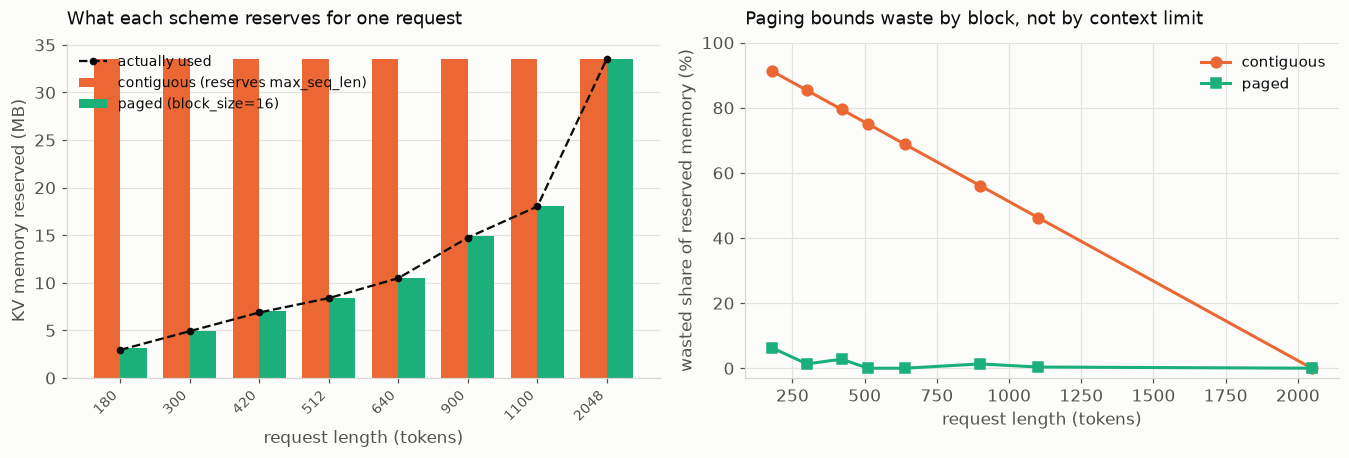

In [23]:
figure, (left, right) = plt.subplots(1, 2, figsize=(12.4, 4.3))
lengths = [r["length"] for r in waste_rows]
index = range(len(lengths))
width = 0.38

left.bar([i - width / 2 for i in index], [r["contiguous"] / 1e6 for r in waste_rows], width,
         label="contiguous (reserves max_seq_len)", color=DECODE_COLOR)
left.bar([i + width / 2 for i in index], [r["paged"] / 1e6 for r in waste_rows], width,
         label=f"paged (block_size={BLOCK_SIZE})", color=ACCENT_COLOR)
left.plot(list(index), [r["used"] / 1e6 for r in waste_rows], color=INK, linestyle="--",
          linewidth=1.5, marker="o", markersize=4, label="actually used")
left.set_xticks(list(index)); left.set_xticklabels(lengths, rotation=45, ha="right", fontsize=9)
left.set_xlabel("request length (tokens)"); left.set_ylabel("KV memory reserved (MB)")
left.set_title("What each scheme reserves for one request")
left.legend(frameon=False, fontsize=9)
left.grid(axis="x", visible=False)

right.plot(lengths, [r["waste_contiguous"] * 100 for r in waste_rows], marker="o",
           color=DECODE_COLOR, label="contiguous")
right.plot(lengths, [r["waste_paged"] * 100 for r in waste_rows], marker="s",
           color=ACCENT_COLOR, label="paged")
right.set_xlabel("request length (tokens)"); right.set_ylabel("wasted share of reserved memory (%)")
right.set_title("Paging bounds waste by block, not by context limit")
right.set_ylim(-3, 100)
right.legend(frameon=False, fontsize=9.5)

figure.tight_layout()
plt.show()

In [24]:
# 측정 전 클럭을 다시 올린다. 셀 사이의 파이썬 구간 동안 카드는 유휴 클럭으로
# 떨어지고, 그대로 재면 이 셀에서 '첫 번째로 측정한 것'만 몇 배 느리게 나온다.
opp.warmup_device(DEVICE)

# 그래서 얼마를 치르는가: gather 한 번의 비용
@torch.inference_mode()
def paged_vs_contiguous_read(context: int) -> tuple[float, float]:
    query = torch.randn(BATCH, CFG.n_heads, 1, CFG.head_dim, device=DEVICE, dtype=DTYPE)
    flat = KVCache(n_layers=1, batch_size=BATCH, n_kv_heads=CFG.n_kv_heads,
                   max_seq_len=context, head_dim=CFG.head_dim, device=DEVICE, dtype=DTYPE)
    blocks = PagedKVCache(n_layers=1, batch_size=BATCH, n_kv_heads=CFG.n_kv_heads,
                          max_seq_len=context, head_dim=CFG.head_dim,
                          device=DEVICE, dtype=DTYPE, block_size=BLOCK_SIZE)
    key = torch.randn(BATCH, CFG.n_kv_heads, context, CFG.head_dim, device=DEVICE, dtype=DTYPE)
    flat.write(0, key, key, 0); flat.advance(context)
    blocks.write(0, key, key, 0); blocks.advance(context)
    strategy = make_attention_strategy("decode_nomask")

    def contiguous_path():
        k, v = flat.read(0, context)
        return strategy(query, k, v, query_start=context - 1)

    def paged_path():
        k, v = blocks.read(0, context)
        return strategy(query, k, v, query_start=context - 1)

    flat_ms = prof.timeit(contiguous_path, device=DEVICE, warmup=10, iters=40).ms
    paged_ms = prof.timeit(paged_path, device=DEVICE, warmup=10, iters=40).ms
    del query, flat, blocks, key
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return flat_ms, paged_ms


flat_ms, paged_ms = paged_vs_contiguous_read(LAYOUT_CONTEXT)
print(f"decode attention, one layer, context {LAYOUT_CONTEXT}, batch {BATCH}")
print(f"  contiguous cache : {flat_ms:.4f} ms")
print(f"  paged cache      : {paged_ms:.4f} ms   ({paged_ms / flat_ms:.2f}x)")
print("\n이 차이는 알고리즘의 비용이 아니라 이 구현의 비용이다.")
print("PagedKVCache.read() 는 블록을 모아 하나의 텐서로 '복사'한다 — §8이 비싸다고 한 바로 그 복사다.")
print("실제 PagedAttention 커널은 block table 을 들고 블록을 제자리에서 읽어 이 복사를 하지 않는다.")

decode attention, one layer, context 2048, batch 8
  contiguous cache : 0.2731 ms
  paged cache      : 0.3487 ms   (1.28x)

이 차이는 알고리즘의 비용이 아니라 이 구현의 비용이다.
PagedKVCache.read() 는 블록을 모아 하나의 텐서로 '복사'한다 — §8이 비싸다고 한 바로 그 복사다.
실제 PagedAttention 커널은 block table 을 들고 블록을 제자리에서 읽어 이 복사를 하지 않는다.


### 여기서 읽어야 할 것

**메모리 논거는 압도적입니다.** 요청 길이가 제각각인 현실적인 묶음에서
사전할당 방식은 대부분의 메모리를 쓰지도 않을 자리에 묶어 둡니다.
페이징은 그 낭비를 마지막 블록 하나로 제한하죠. 같은 GPU로 몇 배 많은 요청을 받는다는 뜻이고,
이건 커널 최적화 몇 퍼센트와는 차원이 다른 이득입니다.

**속도 논거는 이 구현에서는 지지 않습니다** — 그리고 그걸 숨기면 안 됩니다.
`PagedKVCache.read()`는 흩어진 블록을 모아 연속 텐서를 만듭니다. §8에서 배운 대로
그 복사가 비용이죠. 순수 PyTorch로 블록 캐시를 가르치려면 치러야 하는 값입니다.

**진짜 PagedAttention은 그 복사를 하지 않습니다.** 커널이 block table을 직접 받아
블록이 놓인 자리에서 읽습니다. §8에서 확인한 사실 — 커널은 stride를 감당한다 —
이 그걸 가능하게 합니다. 그래서 실제 엔진에서는 메모리 이득을 거의 공짜로 얻습니다.

**아직 남은 한 가지.** `PagedKVCache`는 시퀀스마다 다른 길이(`lengths`)를 들 수 있지만,
모델의 `forward_decode`는 여전히 배치를 한 덩어리로 전진시킵니다.
즉 **짧은 요청이 먼저 끝나도 그 자리를 바로 내주지 못합니다.**
블록 자료구조는 준비됐고, 그걸 쓰는 스케줄러가 없는 상태죠.
그 스케줄러가 **연속 배칭(continuous batching)** 이고, 3장의 주제입니다.

## §10. Sampling

마지막 연산입니다. 그리고 §2의 분해에서 **빠져 있던** 연산이죠 —
`lm_head`까지만 재고 끝냈으니까요.

logits에서 토큰 하나를 고르는 일입니다. FLOPs로는 무시할 만합니다.
그런데 vocabulary가 32000이면 이야기가 달라집니다.

- **greedy** — argmax 한 번. 축소 연산 하나.
- **top-k** — 상위 $k$개만 고른다. `topk`는 부분 선택이라 전체 정렬보다 싸다.
- **top-p (nucleus)** — 누적 확률이 $p$에 닿을 때까지 모은다. 후보 집합이
  분포에 따라 달라지므로 **전체를 정렬해야** 알 수 있다.

top-p의 정렬은 vocabulary 전체에 걸립니다. 그게 얼마나 하는지 재 봅니다.

In [25]:
from infer_opt.sampling import greedy, sample_top_k, sample_top_p

# 측정 전 클럭을 다시 올린다. 셀 사이의 파이썬 구간 동안 카드는 유휴 클럭으로
# 떨어지고, 그대로 재면 이 셀에서 '첫 번째로 측정한 것'만 몇 배 느리게 나온다.
opp.warmup_device(DEVICE)

@torch.inference_mode()
def sampling_costs(batch: int) -> dict[str, float]:
    logits = torch.randn(batch, CFG.vocab_size, device=DEVICE, dtype=DTYPE)
    generator = None  # CUDA 기본 생성기를 쓴다
    return {
        "greedy": prof.timeit(lambda: greedy(logits), device=DEVICE, warmup=10, iters=50).ms,
        "top-k (k=50)": prof.timeit(lambda: sample_top_k(logits, k=50, generator=generator),
                                    device=DEVICE, warmup=10, iters=50).ms,
        "top-p (p=0.9)": prof.timeit(lambda: sample_top_p(logits, p=0.9, generator=generator),
                                     device=DEVICE, warmup=10, iters=50).ms,
    }


sampling_batches = [1, BATCH, 32]
sampling_table = {b: sampling_costs(b) for b in sampling_batches}

print(f"vocabulary = {CFG.vocab_size}\n")
print(f"{'batch':>6} " + " ".join(f"{name:>15}" for name in sampling_table[1]))
for batch, row in sampling_table.items():
    print(f"{batch:>6} " + " ".join(f"{ms:>15.4f}" for ms in row.values()))

decode_attention_total = DECODE_BD.stages["attention"]
print(f"\n비교: batch {BATCH} 의 decode 스텝에서 attention 전체가 {decode_attention_total:.3f} ms")
print(f"      같은 batch 의 top-p 한 번이 {sampling_table[BATCH]['top-p (p=0.9)']:.3f} ms")
print(f"      -> sampling 이 attention 의 {sampling_table[BATCH]['top-p (p=0.9)'] / decode_attention_total:.0%}")

vocabulary = 32000

 batch          greedy    top-k (k=50)   top-p (p=0.9)
     1          0.0479          0.5645          0.6696
     8          0.0472          0.5656          0.7248
    32          0.0465          0.5650          0.9147

비교: batch 8 의 decode 스텝에서 attention 전체가 4.440 ms
      같은 batch 의 top-p 한 번이 0.725 ms
      -> sampling 이 attention 의 16%


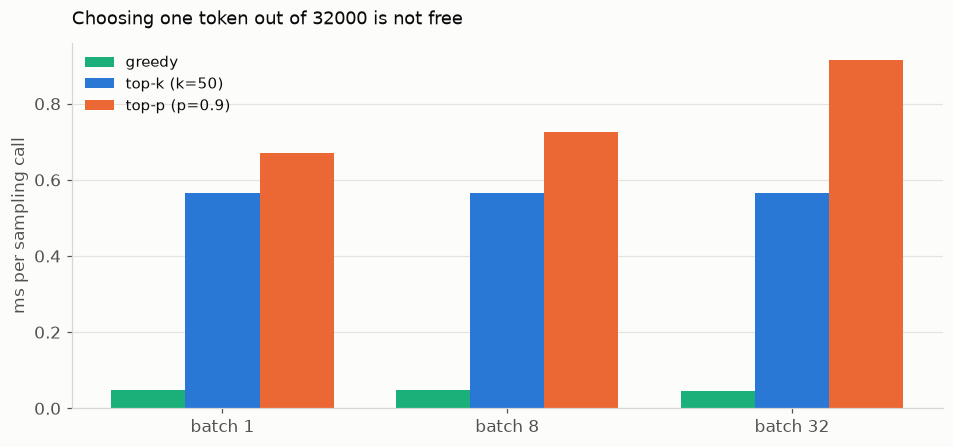

In [26]:
figure, axis = plt.subplots(figsize=(8.8, 4.2))
methods = list(sampling_table[1])
index = range(len(sampling_batches))
width = 0.26
method_colors = [ACCENT_COLOR, PREFILL_COLOR, DECODE_COLOR]

for offset, (method, color) in enumerate(zip(methods, method_colors)):
    values = [sampling_table[b][method] for b in sampling_batches]
    axis.bar([i + (offset - 1) * width for i in index], values, width, label=method, color=color)

axis.set_xticks(list(index)); axis.set_xticklabels([f"batch {b}" for b in sampling_batches])
axis.set_ylabel("ms per sampling call")
axis.set_title(f"Choosing one token out of {CFG.vocab_size} is not free")
axis.legend(frameon=False, fontsize=9.5)
axis.grid(axis="x", visible=False)
figure.tight_layout()
plt.show()

### 여기서 읽어야 할 것

**greedy와 top-p 사이에 십수 배의 차이가 있습니다.** 그리고 top-p의 비용은
batch를 키워도 줄기는커녕 조금씩 늘어납니다 — 정렬은 행마다 독립이고, vocabulary 크기에 걸리니까요.

**batch가 작을수록 이 비용이 아픕니다.** batch 1 decode에서 모델 전체가 memory-bound라
스텝 자체가 짧은데, sampling은 그와 무관하게 고정 비용을 물립니다.
상대 비중이 커지는 거죠.

**실무에서의 함의:** 생성 품질을 위해 top-p를 쓰는 건 정당하지만,
그게 공짜라고 생각하면 안 됩니다. 실제 엔진들은 이 부분을 융합 커널로 처리하거나
(정렬 대신 임계값 탐색), top-k로 후보를 먼저 줄인 뒤 top-p를 적용해
정렬 범위를 $k$개로 좁힙니다.

그리고 이게 **연산 단위 분해를 끝까지 해야 하는 이유**입니다.
`lm_head`에서 멈췄다면 이 비용은 영원히 보이지 않았을 겁니다.

## §11. 정리

### 판별 절차

연산 단위로 내려갈 때는 이 순서로 봅니다.

1. **구간에 이름을 붙이고 device 시간을 귀속시킨다.** 커널 이름만으로는 `q_proj`와 `o_proj`를
   구분할 수 없다. (`opprofile.profile_stages`)
2. **wall과 device의 차이를 먼저 본다.** 그 gap이 크면 지금 보고 있는 비율은 GPU가 아니라
   호스트 이야기다. 배치를 키우거나 CUDA graph를 쓴 뒤 다시 잰다.
3. **시간 비중 옆에 FLOPs 비중을 놓는다.** (`opprofile.stage_flops`)
4. **어긋난 구간을 고른다.** 시간 ≫ FLOPs면 메모리나 커널 실행에 쓰고 있다.
   FLOPs가 0인데 시간을 쓰면 거의 확실히 고칠 것이 있다.
5. **처방을 병목에 맞춘다.** 메모리면 융합·레이아웃·캐시 축소, 실행이면 커널 수 줄이기,
   연산이면 연산량 자체 줄이기.

### 이 장의 결론

| | Prefill | Decode |
|---|---|---|
| 1위 연산 | MLP | Attention |
| attention 모양 | 삼각 마스크가 필요한 $T \times T$ | query 1개, **마스크 불필요** |
| 병목의 성격 | 큰 GEMM, 연산량 | KV 캐시 읽기, 대역폭 |
| KV 캐시 | 쓰기(write)가 주 | 읽기(read)가 주, 문맥따라 증가 |
| 처방 | FlashAttention 계열 커널, chunked prefill | GQA/MQA, 마스크 제거, 페이징, 연속 배칭 |

**연산별로 정리하면:**

| 연산 | 관찰 | 처방 |
|---|---|---|
| Embedding | 무시할 수준 | — |
| RMSNorm | FLOPs 0%, 시간 8~15% | kernel fusion |
| QKV projection | 연산량에 걸맞은 시간 | 양자화 |
| RoPE | FLOPs 0%, 재계산 낭비 + fp16 각도 버그 | 테이블 사전계산 (fp32) |
| Attention | decode 시간의 과반 | tiling(FlashAttention), 마스크 제거, GQA |
| KV cache | `read()`는 view라 공짜, 진짜 비용은 커널 안 | 레이아웃 유지, 페이징 |
| Output projection | 작다 | — |
| MLP | prefill 1위지만 효율적 (시간 < FLOPs) | 연산량 자체를 줄여야 |
| LM head | vocab에 비례 | 어휘 분할, 마지막 위치만 계산 |
| Sampling | top-p가 정렬 때문에 비쌈 | 융합 커널, top-k 선(先)축소 |

**한 줄 요약:** 시간 비중과 FLOPs 비중이 어긋나는 곳이 최적화 대상이고,
decode에서 그 어긋남이 가장 큰 곳은 attention과 그것이 읽는 KV 캐시다.

### 연습문제

1. **숨은 낭비를 하나 더 찾아라.** §3의 표에서 `norm`은 FLOPs 0%에 시간 8~15%다.
   RMSNorm은 읽고-제곱하고-평균내고-곱하는 네 번의 커널로 쪼개져 있다.
   `torch.compile`로 이 구간만 융합하면 몇 배가 줄어드는가? 그리고 그 이득이
   §2의 `gap`을 얼마나 줄이는가?
   *(힌트: `stage_bytes(...)["norm"]`을 재고, 융합 전후의 달성 대역폭을 비교하라.
   커널이 4개에서 1개로 줄면 중간 텐서의 왕복이 사라진다.)*

2. **block size를 고르라.** §9는 `block_size=16`을 썼다. 4, 16, 64, 256으로 바꾸면
   내부 단편화(마지막 블록의 낭비)와 block table의 크기, 그리고 `read()`의 gather 비용이
   각각 어떻게 움직이는가? 어느 지점이 최적이며, 그 답은 평균 요청 길이에 따라 달라지는가?
   *(힌트: 단편화는 `block_size / 2 / 평균길이`에 가깝고, table 크기는 `1/block_size`에 비례한다.
   `PagedKVCache.wasted_bytes`와 §9의 gather 측정을 같이 쓰라.)*

3. **긴 문맥의 예산을 세워라.** 이 모델을 문맥 8192로 서빙하려 한다.
   (a) `n_kv_heads`가 16/4/1일 때 batch 1의 KV 캐시는 각각 몇 MB인가?
   (b) 8 GB 카드에서 가중치를 빼고 남는 메모리로 동시에 몇 개의 요청을 받을 수 있는가?
   (c) §5에서 본 마스크 제거의 이득은 문맥 8192에서 얼마가 되겠는가 — 외삽하고,
   실제로 재서 맞는지 확인하라.
   *(힌트: `prof.kv_cache_bytes`와 `prof.parameter_bytes`. `max_seq_len`을 늘린
   `ModelConfig`를 만들면 (c)는 §5 코드를 그대로 돌릴 수 있다.)*

### 다음 장 예고

2장은 **한 스텝 안**을 봤습니다. 3장은 **스텝들 사이**를 봅니다.

§9에서 블록 자료구조는 만들었지만 그걸 쓸 스케줄러가 없다는 걸 봤습니다 —
짧은 요청이 먼저 끝나도 자리를 내주지 못하죠. **연속 배칭(continuous batching)** 이
그 자리를 즉시 재활용합니다. 그리고 §2의 `gap` — GPU가 놀던 시간 — 은
**CUDA graph**와 **chunked prefill**로 메웁니다.
prefill과 decode를 한 배치에 섞으면 어느 쪽 기계를 돌리게 되는지가 그 장의 질문입니다.